# ¿Cuánto vale un departamento en Buenos Aires?

## Modelo de predicción de precios para propiedades de 1 a 3 ambientes

Análisis exploratorio, preparación iterativa de datos y comparación de modelos de aprendizaje automático sobre avisos inmobiliarios de Properati en la Ciudad de Buenos Aires.

# 1 - Importación de librerías y carga de la base

In [ ]:
from pathlib import Path
import zipfile
import shutil

import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor

In [ ]:
# Detectar la raíz del repositorio tanto al ejecutar desde /notebooks como desde la raíz.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ZIP_PATH = DATA_DIR / "properati.csv.zip"
PARTS = sorted(DATA_DIR.glob("properati.csv.zip.part*"))

if not ZIP_PATH.exists():
    if not PARTS:
        raise FileNotFoundError(
            "No se encontraron las partes de properati.csv.zip en la carpeta data/."
        )
    with ZIP_PATH.open("wb") as destino:
        for parte in PARTS:
            with parte.open("rb") as origen:
                shutil.copyfileobj(origen, destino)

print(f"Base comprimida disponible en: {ZIP_PATH}")
print(f"Partes detectadas: {len(PARTS)}")

In [ ]:
# El ZIP contiene el CSV principal y un archivo auxiliar de macOS; por eso se abre
# explícitamente properati.csv dentro del archivo comprimido.
with zipfile.ZipFile(ZIP_PATH) as archivo_zip:
    with archivo_zip.open("properati.csv") as archivo_csv:
        df = pd.read_csv(archivo_csv, index_col="id")

print(f"Dimensiones de la base original: {df.shape}")

# 2 - ANÁLISIS EXPLORATORIO Y DESCRIPTIVO DE LOS DATOS


## Base original de avisos inmobiliarios

In [ ]:
df.shape

(1000000, 24)

In [ ]:
df.head()

,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,...,bathrooms,surface_total,surface_covered,currency,price_period,title,description,property_type,operation_type,price
id,,,,,,,,,,,,,,,,,,,,,
556713,Propiedad,2019-11-29,9999-12-31,2019-11-29,-58.442399,-34.573623,Argentina,Capital Federal,Colegiales,NaN,...,2.0,NaN,NaN,USD,NaN,"Departamento en Venta en Belgrano, Capital fed...","Sup total por escritura: 96,47 m2 (cubiertos: ...",Departamento,Venta,259000.0
192912,Propiedad,2020-06-05,2020-06-08,2020-06-05,-58.430493,-34.606620,Argentina,Capital Federal,Almagro,NaN,...,2.0,77.0,67.0,USD,NaN,Departamento de 3 ambientes en Venta en Almagro,Excelente departamento de tres ambientes ampli...,Departamento,Venta,235500.0
238224,Propiedad,2020-07-01,9999-12-31,2020-07-01,-58.491760,-34.574123,Argentina,Capital Federal,Villa Urquiza,NaN,...,1.0,60.0,55.0,USD,NaN,Andonaegui 2600 4° - - Departamento en Venta,Excelente 3 ambientes al frente con balcón. Vi...,Departamento,Venta,175000.0
257134,Propiedad,2019-08-17,9999-12-31,2019-08-17,-58.420737,-34.631770,Argentina,Capital Federal,Boedo,NaN,...,1.0,74.0,47.0,USD,NaN,PH Venta Boedo 2 amb Patio,Corredor Responsable: MARCELO TRUJILLO - CPI ...,PH,Venta,140000.0
521738,Propiedad,2019-08-05,2019-08-31,2019-08-05,-58.429983,-34.607225,Argentina,Capital Federal,Almagro,NaN,...,1.0,66.0,64.0,USD,NaN,Venta 3 Ambientes - Almagro - Balcón - Ameniti...,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Venta,173000.0


In [ ]:
df.tail()

,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,...,bathrooms,surface_total,surface_covered,currency,price_period,title,description,property_type,operation_type,price
id,,,,,,,,,,,,,,,,,,,,,
999996,Propiedad,2020-01-09,2020-04-27,2020-01-09,-57.575169,-38.042062,Argentina,Buenos Aires Costa Atlántica,Mar del Plata,NaN,...,5.0,NaN,NaN,USD,NaN,Venta en Bloque,Venta en bloque de esta importante propiedad. ...,Casa,Venta,190000.0
999997,Propiedad,2020-01-09,2020-04-27,2020-01-09,-68.860929,-32.953935,Argentina,Mendoza,Cuadro Benegas,NaN,...,5.0,NaN,NaN,USD,NaN,PALMARES SEGUNDA ETAPA,RIVEROS PROPIEDADES VENDE: Casa Desarrollada E...,Casa,Venta,520000.0
999998,Propiedad,2020-01-09,2020-04-27,2020-01-09,-57.963191,-34.920051,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,NaN,...,5.0,NaN,NaN,ARS,NaN,"Departamento en Alquiler, 44mts, 0 dormitorios...",16 N&deg;706 y 46 se alquila monoambiente e...,Departamento,Alquiler,12000.0
999999,Propiedad,2020-01-09,2020-04-28,2020-01-09,-57.549815,-38.020436,Argentina,Buenos Aires Costa Atlántica,Mar del Plata,NaN,...,5.0,NaN,NaN,USD,NaN,IMPORTANTE RESIDENCIA EN DIVINO ROSTRO,En importante ubicación del tradicional Barrio...,Casa,Venta,550000.0
1000000,Propiedad,2020-01-09,2020-04-28,2020-01-09,NaN,NaN,Argentina,Capital Federal,NaN,NaN,...,5.0,NaN,NaN,ARS,NaN,BARBARO ALQUILA LOCALES EN SAN MARTIN CENTRO,"Barbaro Alquila Galpon , la superficie cubier...",Otro,Venta,800000.0


In [ ]:
df.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lat                float64
lon                float64
l1                  object
l2                  object
l3                  object
l4                  object
l5                  object
l6                 float64
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
price_period        object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
print('Valores de cada variable:')
for c in df.columns:
    print(c, "-->", df[c].unique())


Valores de cada variable:
ad_type --> ['Propiedad']
start_date --> ['2019-11-29' '2020-06-05' '2020-07-01' '2019-08-17' '2019-08-05'
 '2019-10-23' '2019-08-01' '2019-07-24' '2020-06-17' '2019-07-06'
 '2019-12-03' '2020-02-07' '2020-04-28' '2019-11-16' '2019-09-20'
 '2020-04-02' '2020-01-24' '2020-01-17' '2020-05-19' '2020-02-12'
 '2019-12-05' '2019-11-06' '2019-07-26' '2020-02-29' '2020-05-23'
 '2020-03-29' '2020-06-18' '2020-02-26' '2020-05-20' '2019-11-24'
 '2020-01-19' '2019-09-14' '2019-10-13' '2020-05-26' '2019-11-10'
 '2019-11-28' '2020-06-30' '2019-10-11' '2020-07-24' '2019-11-20'
 '2020-05-12' '2020-03-19' '2020-05-13' '2020-05-30' '2020-05-15'
 '2019-12-26' '2019-10-28' '2020-01-03' '2020-01-16' '2019-08-13'
 '2019-11-13' '2020-07-07' '2020-04-24' '2020-02-21' '2020-06-04'
 '2020-03-16' '2019-07-05' '2019-09-09' '2020-03-10' '2020-07-26'
 '2019-11-14' '2020-02-14' '2019-08-18' '2020-06-23' '2020-05-05'
 '2020-01-27' '2020-03-18' '2020-01-14' '2020-06-22' '2020-02-27'
 '2019-09

In [ ]:
print('Frecuencia de cada variable:')
for c in df.columns:
    print(df[c].value_counts())

Frecuencia de cada variable:
ad_type
Propiedad    1000000
Name: count, dtype: int64
start_date
2020-03-21    13194
2020-04-21    13066
2020-02-25    13027
2019-08-01    11418
2020-02-27    10339
              ...  
2019-10-06      175
2019-09-08      155
2019-09-15      143
2019-09-29       99
2019-08-04       95
Name: count, Length: 346, dtype: int64
end_date
9999-12-31    191629
2020-04-28     75473
2020-04-27     20938
2019-12-23     19616
2019-08-14     14571
               ...  
2019-07-07        29
2019-07-05        24
2019-07-08        22
2020-08-22         1
2019-07-04         1
Name: count, Length: 450, dtype: int64
created_on
2020-03-21    13194
2020-04-21    13066
2020-02-25    13027
2019-08-01    11418
2020-02-27    10339
              ...  
2019-10-06      175
2019-09-08      155
2019-09-15      143
2019-09-29       99
2019-08-04       95
Name: count, Length: 346, dtype: int64
lat
-57.526213    1117
-58.455819    1035
-58.579659     951
-57.526213     805
-60.654001     63

## Base Propiedades Capital Federal

In [ ]:
# En la columna l2 se deja solo Capital Federal
df = df[df['l2'] == "Capital Federal"]

In [ ]:
df.shape

(257546, 24)

In [ ]:
df.isna().sum()

ad_type                 0
start_date              0
end_date                0
created_on              0
lat                 32587
lon                 32465
l1                      0
l2                      0
l3                  24324
l4                 247159
l5                 257546
l6                 257546
rooms               78814
bedrooms           129578
bathrooms           37543
surface_total       78050
surface_covered     84513
currency             8291
price_period       157761
title                  23
description             0
property_type           0
operation_type          0
price                7168
dtype: int64

In [ ]:
# Intercambio el nombre de lat y lon
columnas={"lat":"lon","lon":"lat"}

In [ ]:
# Eliminación de columnas
df.drop(["l1", "l5", "l6","l4", "price_period"], axis="columns", inplace = True)
df.rename(columns = columnas, inplace = True)
df.head()


,ad_type,start_date,end_date,created_on,lon,lat,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,currency,title,description,property_type,operation_type,price
id,,,,,,,,,,,,,,,,,,,
556713,Propiedad,2019-11-29,9999-12-31,2019-11-29,-58.442399,-34.573623,Capital Federal,Colegiales,3.0,2.0,2.0,NaN,NaN,USD,"Departamento en Venta en Belgrano, Capital fed...","Sup total por escritura: 96,47 m2 (cubiertos: ...",Departamento,Venta,259000.0
192912,Propiedad,2020-06-05,2020-06-08,2020-06-05,-58.430493,-34.606620,Capital Federal,Almagro,3.0,2.0,2.0,77.0,67.0,USD,Departamento de 3 ambientes en Venta en Almagro,Excelente departamento de tres ambientes ampli...,Departamento,Venta,235500.0
238224,Propiedad,2020-07-01,9999-12-31,2020-07-01,-58.491760,-34.574123,Capital Federal,Villa Urquiza,2.0,NaN,1.0,60.0,55.0,USD,Andonaegui 2600 4° - - Departamento en Venta,Excelente 3 ambientes al frente con balcón. Vi...,Departamento,Venta,175000.0
257134,Propiedad,2019-08-17,9999-12-31,2019-08-17,-58.420737,-34.631770,Capital Federal,Boedo,2.0,1.0,1.0,74.0,47.0,USD,PH Venta Boedo 2 amb Patio,Corredor Responsable: MARCELO TRUJILLO - CPI ...,PH,Venta,140000.0
521738,Propiedad,2019-08-05,2019-08-31,2019-08-05,-58.429983,-34.607225,Capital Federal,Almagro,3.0,2.0,1.0,66.0,64.0,USD,Venta 3 Ambientes - Almagro - Balcón - Ameniti...,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Venta,173000.0


In [ ]:
# Valores faltantes
df.isna().sum()

ad_type                 0
start_date              0
end_date                0
created_on              0
lon                 32587
lat                 32465
l2                      0
l3                  24324
rooms               78814
bedrooms           129578
bathrooms           37543
surface_total       78050
surface_covered     84513
currency             8291
title                  23
description             0
property_type           0
operation_type          0
price                7168
dtype: int64

In [ ]:
for c in df.columns:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False))  # Incluye valores nulos en el conteo
    print(f"Valores nulos: {df[c].isnull().sum()}")
    print("\n")

--- ad_type ---
ad_type
Propiedad    257546
Name: count, dtype: int64
Valores nulos: 0


--- start_date ---
start_date
2019-08-01    5664
2019-10-12    4241
2019-08-13    4236
2019-09-14    3431
2020-01-24    3321
              ... 
2019-12-15      74
2019-08-04      48
2019-09-08      41
2019-09-29      38
2019-09-15      32
Name: count, Length: 346, dtype: int64
Valores nulos: 0


--- end_date ---
end_date
9999-12-31    36726
2020-04-28    13267
2019-12-23     9255
2019-08-14     6996
2019-09-04     4638
              ...  
2020-01-12       13
2019-07-17       12
2019-07-22       10
2019-09-16        9
2019-07-08        6
Name: count, Length: 448, dtype: int64
Valores nulos: 0


--- created_on ---
created_on
2019-08-01    5664
2019-10-12    4241
2019-08-13    4236
2019-09-14    3431
2020-01-24    3321
              ... 
2019-12-15      74
2019-08-04      48
2019-09-08      41
2019-09-29      38
2019-09-15      32
Name: count, Length: 346, dtype: int64
Valores nulos: 0


--- lon ---
l

In [ ]:
# Frecuencias para cada valor de la variable
for c in df.columns:
    print(df[c].value_counts())

ad_type
Propiedad    257546
Name: count, dtype: int64
start_date
2019-08-01    5664
2019-10-12    4241
2019-08-13    4236
2019-09-14    3431
2020-01-24    3321
              ... 
2019-12-15      74
2019-08-04      48
2019-09-08      41
2019-09-29      38
2019-09-15      32
Name: count, Length: 346, dtype: int64
end_date
9999-12-31    36726
2020-04-28    13267
2019-12-23     9255
2019-08-14     6996
2019-09-04     4638
              ...  
2020-01-12       13
2019-07-17       12
2019-07-22       10
2019-09-16        9
2019-07-08        6
Name: count, Length: 448, dtype: int64
created_on
2019-08-01    5664
2019-10-12    4241
2019-08-13    4236
2019-09-14    3431
2020-01-24    3321
              ... 
2019-12-15      74
2019-08-04      48
2019-09-08      41
2019-09-29      38
2019-09-15      32
Name: count, Length: 346, dtype: int64
lon
-58.455819    1035
-58.421008     633
-58.440873     630
-58.417970     555
-58.436266     374
              ... 
-58.415142       1
-58.419613       1
-58.

### Medidas *estadisticas*

In [ ]:
df.describe()

,lon,lat,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,224959.000000,225081.000000,178732.000000,127968.00000,220003.000000,179496.000000,173033.000000,2.503780e+05
mean,-58.494176,-34.576492,2.606864,1.94855,1.540002,166.021243,178.525380,2.471527e+05
std,0.699190,0.394390,1.511721,2.88253,0.984241,986.291073,3045.670277,8.637401e+05
min,-71.658058,-53.788249,1.000000,-2.00000,1.000000,0.000000,-130.000000,0.000000e+00
25%,-58.458038,-34.612754,2.000000,1.00000,1.000000,43.000000,40.000000,3.500000e+04
50%,-58.432667,-34.598421,2.000000,2.00000,1.000000,68.000000,60.000000,1.160000e+05
75%,-58.405243,-34.582226,3.000000,3.00000,2.000000,129.000000,104.000000,2.250000e+05
max,-53.828578,1.000000,40.000000,303.00000,20.000000,126062.000000,1000000.000000,1.111111e+08


In [ ]:
df.median(numeric_only=True)

lon                   -58.432667
lat                   -34.598421
rooms                   2.000000
bedrooms                2.000000
bathrooms               1.000000
surface_total          68.000000
surface_covered        60.000000
price              116000.000000
dtype: float64

In [ ]:
df.mode()

,ad_type,start_date,end_date,created_on,lon,lat,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,currency,title,description,property_type,operation_type,price
0,Propiedad,2019-08-01,9999-12-31,2019-08-01,-58.455819,-34.579326,Capital Federal,Palermo,2.0,1.0,1.0,40.0,40.0,USD,Departamento de 2 ambientes en Venta en Villa ...,Casa Crespo es el primer edificio Premium que ...,Departamento,Venta,25000.0


In [ ]:
df.var(numeric_only=True)

lon                4.888665e-01
lat                1.555438e-01
rooms              2.285300e+00
bedrooms           8.308980e+00
bathrooms          9.687308e-01
surface_total      9.727701e+05
surface_covered    9.276107e+06
price              7.460470e+11
dtype: float64

In [ ]:
# Seleccionamos las variables numéricas
df_num = df.select_dtypes(include=['number'])

In [ ]:
df_num.corr()

,lon,lat,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
lon,1.000000,-0.111297,-0.052682,-0.004267,-0.000983,-0.042129,-0.002448,-0.018538
lat,-0.111297,1.000000,0.032875,-0.004893,-0.013765,0.031527,-0.006861,0.023462
rooms,-0.052682,0.032875,1.000000,0.903134,0.622443,0.085869,0.088368,0.100884
bedrooms,-0.004267,-0.004893,0.903134,1.000000,0.642453,0.092905,0.018536,0.046111
bathrooms,-0.000983,-0.013765,0.622443,0.642453,1.000000,0.172599,0.043142,0.152254
surface_total,-0.042129,0.031527,0.085869,0.092905,0.172599,1.000000,0.341763,0.090820
surface_covered,-0.002448,-0.006861,0.088368,0.018536,0.043142,0.341763,1.000000,0.022147
price,-0.018538,0.023462,0.100884,0.046111,0.152254,0.090820,0.022147,1.000000


In [ ]:
df1 = df.copy()

## MODELO 1

In [ ]:
df5 = df1.copy()

In [ ]:
df5.shape

(257546, 19)

In [ ]:
df5.isna().sum()

ad_type                 0
start_date              0
end_date                0
created_on              0
lon                 32587
lat                 32465
l2                      0
l3                  24324
rooms               78814
bedrooms           129578
bathrooms           37543
surface_total       78050
surface_covered     84513
currency             8291
title                  23
description             0
property_type           0
operation_type          0
price                7168
dtype: int64

In [ ]:
df5.fillna(0, inplace=True)

In [ ]:
df5.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df5 = df5.select_dtypes(exclude=["object"])

In [ ]:
X = df5[df5.columns.drop("price")]
y = df5["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

899118.2112995145

# 3 - LIMPIEZA

# 3.1 - DATOS FALTANTES: ELIMINACIÓN / IMPUTACIÓN

## l3

In [ ]:
# Se agrupa por 'l3' y se calcula las coordenadas de lat y lon promedio
coordenadas_l3 = df1.groupby('l3').agg({'lat': 'mean', 'lon': 'mean'}).reset_index()

for index, row in coordenadas_l3.iterrows():
    print(f"Barrio: {row['l3']}, Latitud: {row['lat']}, Longitud: {row['lon']}")

Barrio: Abasto, Latitud: -34.604064840416804, Longitud: -58.41262879361847
Barrio: Agronomía, Latitud: -34.59453305631494, Longitud: -58.48902185972594
Barrio: Almagro, Latitud: -34.598807553238146, Longitud: -58.42164427979189
Barrio: Balvanera, Latitud: -34.60978255838594, Longitud: -58.40287735224613
Barrio: Barracas, Latitud: -34.63895244581184, Longitud: -58.376543035285
Barrio: Barrio Norte, Latitud: -34.59329866541454, Longitud: -58.401911325241976
Barrio: Belgrano, Latitud: -34.56265459245225, Longitud: -58.453004184220575
Barrio: Boca, Latitud: -34.63542974935326, Longitud: -58.36210656073472
Barrio: Boedo, Latitud: -34.62762866078414, Longitud: -58.417981627716856
Barrio: Caballito, Latitud: -34.61712805480741, Longitud: -58.442113164208216
Barrio: Catalinas, Latitud: -34.59867703734153, Longitud: -58.376589385412096
Barrio: Centro / Microcentro, Latitud: -34.603696766411765, Longitud: -58.37996209810544
Barrio: Chacarita, Latitud: -34.588594273497854, Longitud: -58.450997981

In [ ]:
# Dccionario para mapear las coordenadas promedio
diccionario_coordenadas = coordenadas_l3.set_index('l3')[['lat', 'lon']].to_dict('index')

# Se busca el l3 más cercano basado en las coordenadas y se imputa a los NaN de l3
def encontrar_barrio_mas_cercano(lat, lon, diccionario_coordenadas):
    distancia_minima = float('inf')
    barrio_mas_cercano = None
    for barrio, coords in diccionario_coordenadas.items():
        distancia = np.sqrt((lat - coords['lat'])**2 + (lon - coords['lon'])**2)
        if distancia < distancia_minima:
            distancia_minima = distancia
            barrio_mas_cercano = barrio
    return barrio_mas_cercano

def imputar_l3(row, diccionario_coordenadas):
    if pd.isna(row['l3']) and pd.notna(row['lat']) and pd.notna(row['lon']):
        return encontrar_barrio_mas_cercano(row['lat'], row['lon'], diccionario_coordenadas)
    return row['l3']

df1['l3'] = df1.apply(lambda row: imputar_l3(row, diccionario_coordenadas), axis=1)

In [ ]:
# Se eliminan los NaN 'l3'
df1.dropna(subset=['l3'], inplace=True)
valores_faltantes = df1[df1['l3'].isna()]
print("Valores faltantes en 'l3':", len(valores_faltantes))

Valores faltantes en 'l3': 0


In [ ]:
# Reemplazar "distrito audiovisual" con "chacarita" en la columna 'l3'
df1['l3'] = df1['l3'].replace('Distrito Audiovisual', 'Chacarita')

## MODELO 2


In [ ]:
df6 = df1.copy()

In [ ]:
df6.shape

(236253, 19)

In [ ]:
df6.isna().sum()

ad_type                 0
start_date              0
end_date                0
created_on              0
lon                 11294
lat                 11180
l2                      0
l3                      0
rooms               63349
bedrooms           113188
bathrooms           33754
surface_total       57108
surface_covered     64188
currency             7840
title                  23
description             0
property_type           0
operation_type          0
price                6729
dtype: int64

In [ ]:
df6.fillna(0, inplace=True)

In [ ]:
df6.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df6 = df6.select_dtypes(exclude=["object"])

In [ ]:
X = df6[df6.columns.drop("price")]
y = df6["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

876814.3182301214

## Lat y Lon

In [ ]:
# max/min de lat y lon
lat_max = df1['lat'].max()
lat_min = df1['lat'].min()
lon_max = df1['lon'].max()
lon_min = df1['lon'].min()
print(f"Latitud - Máximo: {lat_max}, Mínimo: {lat_min}")
print(f"Longitud - Máximo: {lon_max}, Mínimo: {lon_min}")


Latitud - Máximo: 1.0, Mínimo: -53.788249
Longitud - Máximo: -53.8285784574, Mínimo: -71.6580585


In [ ]:
# Se imputa NaN en 'lat' y 'lon' usando coordenadas (obtenidas en l3)
def imputar_lat_lon(row, diccionario_coordenadas):
    if pd.notna(row['l3']):
        if pd.isna(row['lat']):
            row['lat'] = diccionario_coordenadas[row['l3']]['lat']
        if pd.isna(row['lon']):
            row['lon'] = diccionario_coordenadas[row['l3']]['lon']
    return row

df1 = df1.apply(lambda row: imputar_lat_lon(row, diccionario_coordenadas), axis=1)

In [ ]:
# Propiedades fuera de los puntos extremos de lat y lon de Capital Federal
fuera_caba = df1[(df1['lat'] < -34.7000) | (df1['lat'] > -34.5333) | (df1['lon'] < -58.5333) | (df1['lon'] > -58.3333)]
fuera_caba

,ad_type,start_date,end_date,created_on,lon,lat,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,currency,title,description,property_type,operation_type,price
id,,,,,,,,,,,,,,,,,,,
352714,Propiedad,2020-01-14,9999-12-31,2020-01-14,-60.628453,-32.952315,Capital Federal,Saavedra,3.0,1.0,1.0,NaN,NaN,USD,DEPARTAMENTO A ESTRENAR 1 DORMITORIO CON BALCO...,Edificio SOL PATAGONIA XXII\n\nUbicaci&oacute...,Departamento,Venta,135200.0
82980,Propiedad,2019-12-07,2019-12-17,2019-12-07,-68.468140,-33.081030,Capital Federal,Villa Real,3.0,2.0,1.0,90.0,90.0,USD,DEPTO 3 AMBIENTES C/PATIO- VENTA- GRAL. SAN MA...,Corredor Responsable: Jorge Roca - CMCPSM 2550...,Departamento,Venta,185000.0
78598,Propiedad,2019-10-28,2019-11-04,2019-10-28,-68.468140,-33.081030,Capital Federal,Villa Real,3.0,2.0,1.0,50.0,47.0,USD,Se vende 3 ambientes con balcon - Villa Balle...,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Venta,85000.0
516258,Propiedad,2020-06-13,2020-06-16,2020-06-13,-58.415032,-34.304431,Capital Federal,Nuñez,2.0,1.0,1.0,67.0,41.0,USD,2 Ambientes C/Patio A Estrenar / Mudate YA !!...,Dormitorio con placard y estar cocina con sali...,Departamento,Venta,129000.0
296252,Propiedad,2020-02-06,9999-12-31,2020-02-06,-60.661584,-32.938420,Capital Federal,Saavedra,2.0,1.0,1.0,NaN,NaN,USD,VENDO DEPARTAMENTO 1 DORMITORIO CON BALCON - T...,URQUIZA 2800 \nZONA UNIVERSITARIA - MERCADO DE...,Departamento,Venta,76930.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998844,Propiedad,2020-01-09,2020-04-27,2020-01-09,-58.995388,-27.459029,Capital Federal,Nuñez,3.0,2.0,2.0,NaN,NaN,ARS,Dpto. 2 dorm. c/ cochera,"Departamento de 2 dormitorios con placar, coci...",Departamento,Alquiler,18000.0
999021,Propiedad,2020-01-09,2020-08-05,2020-01-09,-68.888010,-33.029922,Capital Federal,Villa Real,6.0,4.0,3.0,NaN,NaN,ARS,CASA NATANIA,MICHELETTI INMOBILIARIA ALQUILA HERMOSA CASA e...,PH,Alquiler,30000.0
999022,Propiedad,2020-01-09,2020-03-05,2020-01-09,-68.860988,-32.953850,Capital Federal,Villa Real,4.0,3.0,3.0,NaN,NaN,USD,Barrio Privado Palmares,"Barrio Privado Palmares\nCasa en dos plantas, ...",PH,Venta,470000.0


In [ ]:
# Se eliminan las propiedades con puntos extremos fuera de Capital Federal
df1= df1.drop(fuera_caba.index)

## MODELO 3

In [ ]:
df7 = df1.copy()

In [ ]:
df7.shape

(232907, 19)

In [ ]:
df7.isna().sum()

ad_type                 0
start_date              0
end_date                0
created_on              0
lon                     0
lat                     0
l2                      0
l3                      0
rooms               62370
bedrooms           112152
bathrooms           32911
surface_total       54456
surface_covered     61614
currency             7736
title                  23
description             0
property_type           0
operation_type          0
price                6630
dtype: int64

In [ ]:
df7.fillna(0, inplace=True)

In [ ]:
df7.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df7= df7.select_dtypes(exclude=["object"])

In [ ]:
X = df7[df7.columns.drop("price")]
y = df7["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

918927.6491623032

## Price

In [ ]:
# Máximo y mínimo de la columna price
price_max = df1['price'].max()
price_min = df1['price'].min()

print(f"Precio - Máximo: {price_max}, Mínimo: {price_min}")

Precio - Máximo: 32434232.0, Mínimo: 0.0


In [ ]:
# Conversión de ARS a USD y cambio de nombre del atributo
df1.loc[df1['currency'] == 'ARS', 'price'] = df1.loc[df1['currency'] == 'ARS', 'price'] / 68
df1.loc[df1['currency'] == 'ARS', 'currency'] = 'USD'

In [ ]:
# Publicaciones que no indican el precio de la propiedad, se eliminan
price_nulos= df1.loc[df1["price"].isna()]
df1 = df1.dropna(subset=["price"])

## Currency

In [ ]:
# Los NaN de currency coinciden con un precio = 0. Se eliminan.
currency_nulos= df1.loc[df1["currency"].isna()]
df1 = df1.dropna(subset=["currency"])

## Date cambio

In [ ]:
# Se cambia el año de baja del aviso de 9999 por 2020
df1.loc[df1['end_date'] == '9999-12-31', 'end_date'] = df1.loc[df1['end_date'] == '9999-12-31', 'end_date'].str.replace('9999', '2020')

## Title

In [ ]:
df1.dropna(subset=['title'], inplace=True)

## MODELO 4

In [ ]:
df8 = df1.copy()

In [ ]:
df8.shape

(225152, 19)

In [ ]:
df8.isna().sum()

ad_type                 0
start_date              0
end_date                0
created_on              0
lon                     0
lat                     0
l2                      0
l3                      0
rooms               59181
bedrooms           107729
bathrooms           31083
surface_total       53782
surface_covered     60127
currency                0
title                   0
description             0
property_type           0
operation_type          0
price                   0
dtype: int64

In [ ]:
df8.fillna(0, inplace=True)

In [ ]:
df8.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df8= df8.select_dtypes(exclude=["object"])

In [ ]:
X = df8[df8.columns.drop("price")]
y = df8["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

406063.3049913083

## property_type

In [ ]:
df1["property_type"].unique()


array(['Departamento', 'PH', 'Lote', 'Otro', 'Oficina', 'Depósito',
       'Local comercial', 'Casa', 'Cochera', 'Casa de campo'],
      dtype=object)

In [ ]:
df1["property_type"].value_counts()

property_type
Departamento       150750
Otro                16992
Oficina             12543
Local comercial     12376
PH                  12156
Lote                 7604
Casa                 7544
Cochera              3421
Depósito             1762
Casa de campo           4
Name: count, dtype: int64

In [ ]:
# Se filtra y se dejan los atributos que corresponden para el análisis
df1 = df1[df1["property_type"].isin(["Departamento", "PH", "Casa"])]

In [ ]:
df1["property_type"].value_counts()

property_type
Departamento    150750
PH               12156
Casa              7544
Name: count, dtype: int64

## MODELO 5


In [ ]:
df9 = df1.copy()

In [ ]:
df9.shape

(170450, 19)

In [ ]:
df9.isna().sum()

ad_type                0
start_date             0
end_date               0
created_on             0
lon                    0
lat                    0
l2                     0
l3                     0
rooms              11956
bedrooms           56135
bathrooms           8251
surface_total      31443
surface_covered    31813
currency               0
title                  0
description            0
property_type          0
operation_type         0
price                  0
dtype: int64

In [ ]:
df9.fillna(0, inplace=True)

In [ ]:
df9.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df9= df9.select_dtypes(exclude=["object"])

In [ ]:
X = df9[df9.columns.drop("price")]
y = df9["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

236118.51331457458

## operation_type

In [ ]:
# Frecuencia de cada categoría en operation_type
frecuencia_operation_type = df1['operation_type'].value_counts()
print("\nFrecuencia de cada categoría en operation_type:")
print(frecuencia_operation_type)


Frecuencia de cada categoría en operation_type:
operation_type
Venta                120528
Alquiler              37392
Alquiler temporal     12530
Name: count, dtype: int64


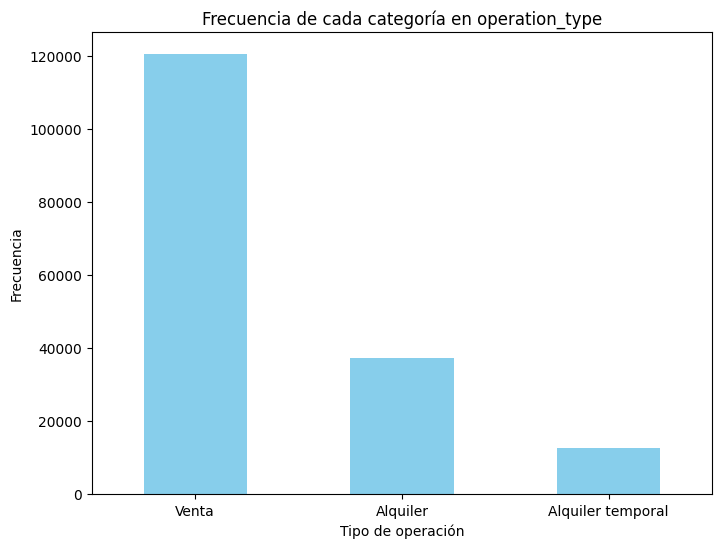

In [ ]:
# Visualización de los datos
plt.figure(figsize=(8, 6))
frecuencia_operation_type.plot(kind='bar', color='skyblue')
plt.title('Frecuencia de cada categoría en operation_type')
plt.xlabel('Tipo de operación')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Se agrupa por operation_type y calcula estadísticas descriptivas para price
estadisticas_por_tipo = df1.groupby('operation_type')['price'].describe()
print("\nEstadísticas descriptivas de price por tipo de operación:")
print(estadisticas_por_tipo)


Estadísticas descriptivas de price por tipo de operación:
                      count           mean            std          min  \
operation_type                                                           
Alquiler            37392.0     840.642124    2505.640760    36.764706   
Alquiler temporal   12530.0     781.560234    2472.148373    32.352941   
Venta              120528.0  246850.099340  343220.075456  3088.235294   

                             25%            50%            75%         max  
operation_type                                                              
Alquiler              235.294118     323.529412     558.823529    100000.0  
Alquiler temporal     382.352941     500.000000     735.294118     99000.0  
Venta              110000.000000  163000.000000  260001.000000  32434232.0  


<Figure size 1000x600 with 0 Axes>

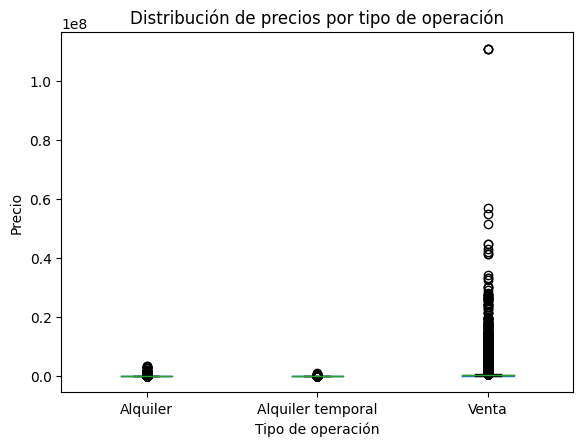

In [ ]:
# Visualizar resultados
plt.figure(figsize=(10, 6))
df.boxplot(column='price', by='operation_type', grid=False, showfliers=True)
plt.title('Distribución de precios por tipo de operación')
plt.suptitle('')
plt.xlabel('Tipo de operación')
plt.ylabel('Precio')
plt.show()

In [ ]:
# Intervalos de precios para cada categoría
bins = [0, 1000, 5000, 10000, 12000, 15000, 20000, 50000, 100000, 200000, 500000, 1000000]

df1['price_bins'] = pd.cut(df1['price'], bins)

frecuencia_categorias = pd.crosstab(df1['price_bins'], df1['operation_type'])

print("\nFrecuencia de cada categoría de operation_type dentro de cada intervalo de precio:")
print(frecuencia_categorias)


Frecuencia de cada categoría de operation_type dentro de cada intervalo de precio:
operation_type     Alquiler  Alquiler temporal  Venta
price_bins                                           
(0, 1000]             31470              10753      0
(1000, 5000]           5110               1723     50
(5000, 10000]           634                 18     95
(10000, 12000]           44                  1     11
(12000, 15000]           34                  2     12
(15000, 20000]           31                  7     12
(20000, 50000]           53                 17    822
(50000, 100000]          16                  9  23198
(100000, 200000]          0                  0  51630
(200000, 500000]          0                  0  35175
(500000, 1000000]         0                  0   6733


In [ ]:
# Se elimina las categorías "Alquiler" y "Alquiler temporal" de operation_type
df1= df1.loc[~df1['operation_type'].isin(['Alquiler', 'Alquiler temporal'])]

In [ ]:
# Se elimina la variable price_bins
df1 = df1.drop(columns=['price_bins'])

## MODELO 6

In [ ]:
df10 = df1.copy()

In [ ]:
df10.shape

(83791, 19)

In [ ]:
df10.isna().sum()

ad_type                0
start_date             0
end_date               0
created_on             0
lon                    0
lat                    0
l2                     0
l3                     0
rooms                  0
bedrooms           25786
bathrooms           3165
surface_total      14615
surface_covered    13692
currency               0
title                  0
description            0
property_type          0
operation_type         0
price                  0
dtype: int64

In [ ]:
df10.fillna(0, inplace=True)

In [ ]:
df10.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df10= df10.select_dtypes(exclude=["object"])

In [ ]:
X = df10[df10.columns.drop("price")]
y = df10["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

87116.72626552876

## Rooms

In [ ]:
# Se calcula la mediana de 'rooms' por cada barrio 'l3'
medianas_por_barrio = df1.groupby('l3')['rooms'].median()
print(medianas_por_barrio)


l3
Abasto                  2.0
Agronomía               2.0
Almagro                 2.0
Balvanera               2.0
Barracas                2.0
Barrio Norte            2.0
Belgrano                2.0
Boca                    2.0
Boedo                   2.0
Caballito               2.0
Catalinas               3.0
Centro / Microcentro    2.0
Chacarita               2.0
Coghlan                 2.0
Colegiales              2.0
Congreso                2.0
Constitución            2.0
Flores                  2.0
Floresta                2.0
Las Cañitas             2.0
Liniers                 2.0
Mataderos               3.0
Monserrat               2.0
Monte Castro            2.0
Nuñez                   2.0
Once                    3.0
Palermo                 2.0
Parque Avellaneda       3.0
Parque Centenario       3.0
Parque Chacabuco        2.0
Parque Chas             2.0
Parque Patricios        2.0
Paternal                2.0
Pompeya                 2.0
Puerto Madero           2.0
Recoleta         

In [ ]:
# Se imputan valores NaN
df1['rooms'].fillna(df1['l3'].map(medianas_por_barrio), inplace=True)


In [ ]:
# Se dejan las propiedades hasta tres ambientes
df1= df1.loc[df['rooms'] <= 3]
print(df1['rooms'].value_counts())

rooms
2.0    31293
3.0    30804
1.0    21694
Name: count, dtype: int64


## MODELO 7

In [ ]:
df11 = df1.copy()

In [ ]:
df11.shape

(83791, 19)

In [ ]:
df11.isna().sum()

ad_type                0
start_date             0
end_date               0
created_on             0
lon                    0
lat                    0
l2                     0
l3                     0
rooms                  0
bedrooms           25786
bathrooms           3165
surface_total      14615
surface_covered    13692
currency               0
title                  0
description            0
property_type          0
operation_type         0
price                  0
dtype: int64

In [ ]:
df11.fillna(0, inplace=True)

In [ ]:
df11.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df11= df11.select_dtypes(exclude=["object"])

In [ ]:
X = df11[df11.columns.drop("price")]
y = df11["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

87116.72626552876

## Bedrooms

In [ ]:
# Se calcula la mediana de 'bedrooms' por cada barrio 'l3'
medianas_por_barrio = df1.groupby('l3')['bedrooms'].median()
print(medianas_por_barrio)


l3
Abasto                  1.0
Agronomía               1.0
Almagro                 1.0
Balvanera               1.0
Barracas                2.0
Barrio Norte            1.0
Belgrano                1.0
Boca                    1.0
Boedo                   1.0
Caballito               1.0
Catalinas               1.0
Centro / Microcentro    1.0
Chacarita               1.0
Coghlan                 1.0
Colegiales              1.0
Congreso                1.0
Constitución            1.0
Flores                  1.0
Floresta                1.0
Las Cañitas             1.0
Liniers                 1.0
Mataderos               2.0
Monserrat               1.0
Monte Castro            1.0
Nuñez                   1.0
Once                    2.0
Palermo                 1.0
Parque Avellaneda       2.0
Parque Centenario       2.0
Parque Chacabuco        1.0
Parque Chas             1.0
Parque Patricios        2.0
Paternal                1.0
Pompeya                 2.0
Puerto Madero           2.0
Recoleta         

In [ ]:
# Se imputan los NaN de 'bedrooms'
df1['bedrooms'].fillna(df1['l3'].map(medianas_por_barrio), inplace=True)

In [ ]:
# Valores de la variable
print(df1['bedrooms'].value_counts())

bedrooms
1.0     54387
2.0     26771
0.0      2408
3.0       214
4.0         6
11.0        2
15.0        1
10.0        1
6.0         1
Name: count, dtype: int64


In [ ]:
# Definir los valores a excluir
valores_a_excluir = [0, 4, 11, 15, 10, 6]

# Filtrar el DataFrame para mantener solo los valores de 'bedrooms' que no están en la lista de exclusión
df1 = df1[~df1['bedrooms'].isin(valores_a_excluir)]

# Verificar el conteo actualizado de valores únicos de la variable 'bedrooms'
print(df1['bedrooms'].value_counts())

bedrooms
1.0    54387
2.0    26771
3.0      214
Name: count, dtype: int64


## MODELO 8

In [ ]:
df12 = df1.copy()

In [ ]:
df12.shape

(81372, 19)

In [ ]:
df12.isna().sum()

ad_type                0
start_date             0
end_date               0
created_on             0
lon                    0
lat                    0
l2                     0
l3                     0
rooms                  0
bedrooms               0
bathrooms           2841
surface_total      12225
surface_covered    11302
currency               0
title                  0
description            0
property_type          0
operation_type         0
price                  0
dtype: int64

In [ ]:
df12.fillna(0, inplace=True)

In [ ]:
df12.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df12= df12.select_dtypes(exclude=["object"])

In [ ]:
X = df12[df12.columns.drop("price")]
y = df12["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

119206.6261842095

## Bathrooms

In [ ]:
# Se calcula la mediana de 'bathrooms' por cada barrio 'l3'
medianas_por_barrio = df1.groupby('l3')['bathrooms'].median()
print(medianas_por_barrio)


l3
Abasto                  1.0
Agronomía               1.0
Almagro                 1.0
Balvanera               1.0
Barracas                1.0
Barrio Norte            1.0
Belgrano                1.0
Boca                    1.0
Boedo                   1.0
Caballito               1.0
Catalinas               1.0
Centro / Microcentro    1.0
Chacarita               1.0
Coghlan                 1.0
Colegiales              1.0
Congreso                1.0
Constitución            1.0
Flores                  1.0
Floresta                1.0
Las Cañitas             1.0
Liniers                 1.0
Mataderos               1.0
Monserrat               1.0
Monte Castro            1.0
Nuñez                   1.0
Once                    1.0
Palermo                 1.0
Parque Avellaneda       1.0
Parque Centenario       1.0
Parque Chacabuco        1.0
Parque Chas             1.0
Parque Patricios        1.0
Paternal                1.0
Pompeya                 1.0
Puerto Madero           2.0
Recoleta         

In [ ]:
# Se imputan NaN de 'bathrooms'
df1['bathrooms'].fillna(df1['l3'].map(medianas_por_barrio), inplace=True)

In [ ]:
# Valores únicos
print(df1['bathrooms'].value_counts())

bathrooms
1.0     65951
2.0     13732
3.0      1458
4.0       197
5.0        17
6.0         9
11.0        3
10.0        2
7.0         2
20.0        1
Name: count, dtype: int64


In [ ]:
# Valores a excluir
valores_a_excluir = [4, 5, 6, 7, 11, 10, 20]

df1 = df1[~df1['bathrooms'].isin(valores_a_excluir)]
print(df1['bathrooms'].value_counts())

bathrooms
1.0    65951
2.0    13732
3.0     1458
Name: count, dtype: int64


## MODELO 9

In [ ]:
df13 = df1.copy()

In [ ]:
df13.shape

(81141, 19)

In [ ]:
df13.isna().sum()

ad_type                0
start_date             0
end_date               0
created_on             0
lon                    0
lat                    0
l2                     0
l3                     0
rooms                  0
bedrooms               0
bathrooms              0
surface_total      12149
surface_covered    11227
currency               0
title                  0
description            0
property_type          0
operation_type         0
price                  0
dtype: int64

In [ ]:
df13.fillna(0, inplace=True)

In [ ]:
df13.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df13 = df13.select_dtypes(exclude=["object"])

In [ ]:
X = df13[df13.columns.drop("price")]
y = df13["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

162935.65676355307

## Surface_total imputación



In [ ]:
# Mediana de 'surface_total' por cada barrio 'l3'
medianas_por_barrio = df1.groupby('l3')['surface_total'].median()
print(medianas_por_barrio)


l3
Abasto                   43.0
Agronomía                55.0
Almagro                  50.0
Balvanera                48.0
Barracas                 66.0
Barrio Norte             54.0
Belgrano                 57.0
Boca                     54.0
Boedo                    52.0
Caballito                51.0
Catalinas                45.5
Centro / Microcentro     47.0
Chacarita                47.0
Coghlan                  60.0
Colegiales               48.0
Congreso                 45.5
Constitución             48.0
Flores                   55.0
Floresta                 55.0
Las Cañitas              60.0
Liniers                  55.0
Mataderos                70.0
Monserrat                50.0
Monte Castro             53.0
Nuñez                    55.0
Once                     55.0
Palermo                  55.0
Parque Avellaneda        70.0
Parque Centenario        56.0
Parque Chacabuco         55.0
Parque Chas              48.5
Parque Patricios         55.0
Paternal                 52.0
Pompeya

In [ ]:
# Se imputa NaN de 'surface_total'
df1['surface_total'].fillna(df1['l3'].map(medianas_por_barrio), inplace=True)

In [ ]:
# conteo de valores únicos de la variable
print(df1['surface_total'].value_counts())

surface_total
55.0       4389
50.0       2933
57.0       2570
48.0       2456
40.0       2156
           ... 
3750.0        1
3950.0        1
5030.0        1
269.0         1
21920.0       1
Name: count, Length: 439, dtype: int64


## MODELO 10

In [ ]:
df14 = df1.copy()

In [ ]:
df14.shape

(81141, 19)

In [ ]:
df14.isna().sum()

ad_type                0
start_date             0
end_date               0
created_on             0
lon                    0
lat                    0
l2                     0
l3                     0
rooms                  0
bedrooms               0
bathrooms              0
surface_total          0
surface_covered    11227
currency               0
title                  0
description            0
property_type          0
operation_type         0
price                  0
dtype: int64

In [ ]:
df14.fillna(0, inplace=True)

In [ ]:
df14.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df14 = df14.select_dtypes(exclude=["object"])

In [ ]:
X = df14[df14.columns.drop("price")]
y = df14["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

163215.34212026844

## Surface_covered

In [ ]:
# Mediana de 'surface_covered' por barrio 'l3'
medianas_por_barrio = df1.groupby('l3')['surface_covered'].median()
print(medianas_por_barrio)


l3
Abasto                  40.0
Agronomía               44.0
Almagro                 45.0
Balvanera               44.0
Barracas                55.0
Barrio Norte            49.0
Belgrano                50.0
Boca                    50.5
Boedo                   45.0
Caballito               47.0
Catalinas               61.0
Centro / Microcentro    43.0
Chacarita               41.0
Coghlan                 52.0
Colegiales              42.0
Congreso                42.0
Constitución            43.0
Flores                  48.0
Floresta                49.0
Las Cañitas             51.0
Liniers                 45.5
Mataderos               57.5
Monserrat               46.0
Monte Castro            46.0
Nuñez                   48.0
Once                    51.0
Palermo                 49.0
Parque Avellaneda       60.0
Parque Centenario       55.0
Parque Chacabuco        49.0
Parque Chas             45.0
Parque Patricios        50.0
Paternal                46.0
Pompeya                 46.0
Puerto Made

In [ ]:
# Imputar NaN de 'surface_covered'
df1['surface_covered'].fillna(df1['l3'].map(medianas_por_barrio), inplace=True)

In [ ]:
# conteo de valores únicos de la variable
print(df1['surface_covered'].value_counts())

surface_covered
45.0      3049
42.0      2942
48.0      2935
50.0      2862
47.0      2770
          ... 
2912.0       1
11.0         1
4255.0       1
528.0        1
520.0        1
Name: count, Length: 360, dtype: int64


## MODELO 11

In [ ]:
df15 = df1.copy()

In [ ]:
df15.shape

(81141, 19)

In [ ]:
df15.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
dtype: int64

In [ ]:
df15.fillna(0, inplace=True)

In [ ]:
df15.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df15 = df15.select_dtypes(exclude=["object"])

In [ ]:
X = df15[df15.columns.drop("price")]
y = df15["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

162479.71313138583

[Text(0.5, 0.875, 'surface_covered <= 72.5\nfriedman_mse = 27930859004.027\nsamples = 64912\nvalue = 167044.283'),
 Text(0.25, 0.625, 'surface_total <= 50.5\nfriedman_mse = 20631811759.814\nsamples = 55982\nvalue = 143476.268'),
 Text(0.125, 0.375, 'surface_total <= 40.5\nfriedman_mse = 15511464616.056\nsamples = 27681\nvalue = 111970.891'),
 Text(0.0625, 0.125, 'friedman_mse = 909092283.927\nsamples = 13846\nvalue = 94627.426'),
 Text(0.1875, 0.125, 'friedman_mse = 29523137908.218\nsamples = 13835\nvalue = 129328.144'),
 Text(0.375, 0.375, 'bathrooms <= 1.5\nfriedman_mse = 23719566647.822\nsamples = 28301\nvalue = 174291.446'),
 Text(0.3125, 0.125, 'friedman_mse = 27297399144.31\nsamples = 22103\nvalue = 160336.682'),
 Text(0.4375, 0.125, 'friedman_mse = 7789488164.469\nsamples = 6198\nvalue = 224056.232'),
 Text(0.75, 0.625, 'lon <= -58.366\nfriedman_mse = 48377027871.221\nsamples = 8930\nvalue = 314791.721'),
 Text(0.625, 0.375, 'lat <= -34.593\nfriedman_mse = 29022051395.186\nsampl

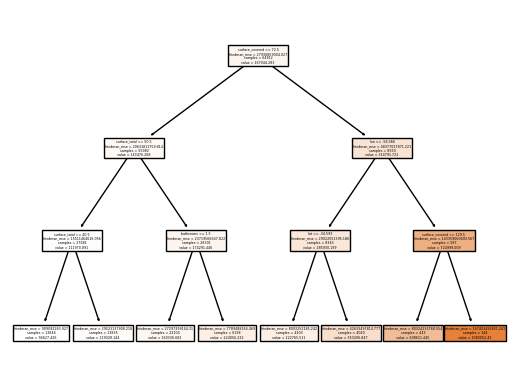

In [ ]:
# Visualización de como el modelo toma las decisiones
sk.tree.plot_tree(reg, feature_names=X_train.columns, filled=True)

# En adelante se divide en dos el análisis, por un lado Puerto Madero (df3) y por el otro el resto de los barrios de Capital Federal (df4)

In [ ]:
df3 = df1.copy()

In [ ]:
df4 = df1.copy()

In [ ]:
# Se divide el DataFrame df1 en df3 (Puerto Madero) y df4 (resto de los barrios)
df3 = df1[df1['l3'] == 'Puerto Madero']
df4 = df1[df1['l3'] != 'Puerto Madero']


In [ ]:
###
df3.shape

(1151, 19)

In [ ]:
###
df4.shape

(79990, 19)

In [ ]:
df3.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
dtype: int64

In [ ]:
df4.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
dtype: int64

# 3.2 - OUTLIERS

## 3.2.1 - Barrios de Capital Federal - df4

### surface_covered

In [ ]:
# Descripción de surface_covered
estadisticas_por_tipo = df4.groupby('surface_covered').describe()
print("\nEstadísticas descriptivas de surface_covered por tipo de operación:")
print(estadisticas_por_tipo)


Estadísticas descriptivas de surface_covered por tipo de operación:
                  lon                                                        \
                count       mean       std        min        25%        50%   
surface_covered                                                               
1.0              29.0 -58.467624  0.025496 -58.518375 -58.483335 -58.465751   
2.0               2.0 -58.475631  0.033766 -58.499507 -58.487569 -58.475631   
3.0               6.0 -58.411830  0.041825 -58.463965 -58.447538 -58.400830   
4.0               3.0 -58.459960  0.030724 -58.495437 -58.468830 -58.442222   
5.0               2.0 -58.405276  0.002845 -58.407288 -58.406282 -58.405276   
...               ...        ...       ...        ...        ...        ...   
10843.0           1.0 -58.372528       NaN -58.372528 -58.372528 -58.372528   
21920.0           1.0 -58.394502       NaN -58.394502 -58.394502 -58.394502   
28750.0           1.0 -58.357414       NaN -58.357414 -58.3574

In [ ]:
# Intervalos variable surface_covered
bins = [-100000, 0, 10, 20, 50, 80, 100, 120, 150, 175, 250, 500, 1000, 10000, 20000, 30000, 100000, 1000000]

surface_covered_bins = pd.cut(df4['surface_covered'], bins=bins)

frecuencia_surface_covered_bins = surface_covered_bins.value_counts().sort_index()

print("Frecuencia de surface_covered:")
print(frecuencia_surface_covered_bins)

Frecuencia de surface_covered:
surface_covered
(-100000, 0]             0
(0, 10]                 55
(10, 20]               424
(20, 50]             48277
(50, 80]             25090
(80, 100]             3924
(100, 120]            1126
(120, 150]             646
(150, 175]             155
(175, 250]             140
(250, 500]              59
(500, 1000]             10
(1000, 10000]           79
(10000, 20000]           1
(20000, 30000]           2
(30000, 100000]          2
(100000, 1000000]        0
Name: count, dtype: int64


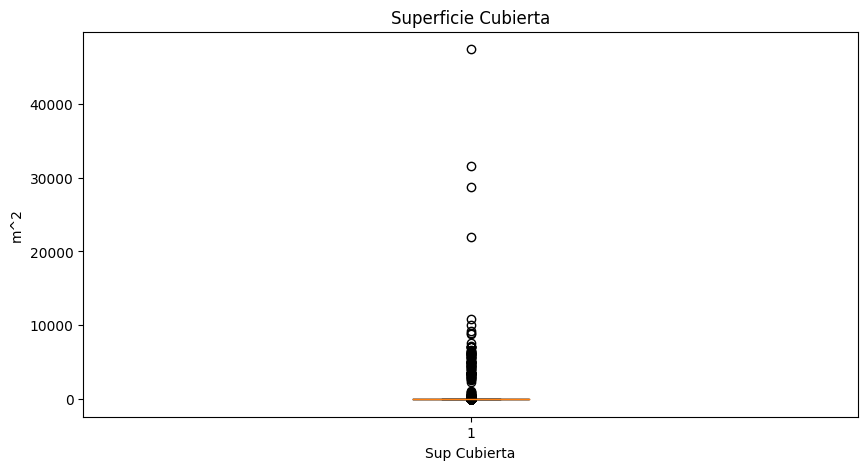

In [ ]:
# Outliers sup cubierta

plt.figure(figsize=(10, 5))  # Configurar el tamaño de la figura
plt.boxplot(df4['surface_covered'])  # Crear el boxplot horizontal
plt.title('Superficie Cubierta')  # Añadir el título del gráfico
plt.xlabel('Sup Cubierta')  # Añadir la etiqueta del eje X
plt.ylabel('m^2')  # Etiqueta del eje Y

plt.show()  # Mostrar el boxplot


In [ ]:
# Calcular los cuartiles y el rango intercuartil (IQR)
Q1 = df4['surface_covered'].quantile(0.20)
Q3 = df4['surface_covered'].quantile(0.80)
IQR = Q3 - Q1

# Determinar los límites inferior y superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Límite inferior: {lower_bound}")
print(f"Límite superior: {upper_bound}")

# Identificar los outliers
outliers = df4[(df4['surface_covered'] < lower_bound) | (df4['surface_covered'] > upper_bound)]
print("\nOutliers:")
print(outliers)

Q1: 36.0
Q3: 65.0
IQR: 29.0
Límite inferior: -7.5
Límite superior: 108.5

Outliers:
          ad_type  start_date    end_date  created_on        lon        lat  \
id                                                                            
578236  Propiedad  2019-08-13  2019-08-14  2019-08-13 -58.415610 -34.608450   
578123  Propiedad  2019-08-13  2019-08-14  2019-08-13 -58.447588 -34.566724   
142348  Propiedad  2019-09-01  2019-09-04  2019-09-01 -58.422300 -34.590509   
697115  Propiedad  2020-05-29  2020-06-25  2020-05-29 -58.413443 -34.586015   
142780  Propiedad  2019-09-01  2019-09-04  2019-09-01 -58.431212 -34.581203   
...           ...         ...         ...         ...        ...        ...   
994235  Propiedad  2020-01-09  2020-02-13  2020-01-09 -58.474729 -34.549756   
997568  Propiedad  2020-01-09  2020-01-22  2020-01-09 -58.460129 -34.561153   
997577  Propiedad  2020-01-09  2020-04-02  2020-01-09 -58.386169 -34.595566   
999180  Propiedad  2020-01-09  2020-01-24  2020

In [ ]:
###
df4.shape

(79990, 19)

In [ ]:
df4 = df4[(df4['surface_covered'] >= 20) & (df4['surface_covered'] <= 120)]

In [ ]:
###
df4.shape


(78582, 19)

In [ ]:
# Frecuencia de surface_covered
frecuencia_surface_covered = df4['surface_covered'].value_counts()

print("Frecuencia de surface_covered:")
print(frecuencia_surface_covered)


Frecuencia de surface_covered:
surface_covered
45.0     3042
42.0     2939
48.0     2921
50.0     2852
47.0     2763
         ... 
116.0      33
111.0      31
118.0      24
114.0      21
119.0       9
Name: count, Length: 108, dtype: int64


### surface_total

In [ ]:
# Intervalos variable surface_total
bins = [-10000, 0, 10, 20, 50, 80, 100, 120, 150, 221, 250, 500, 1000, 10000, 20000, 30000, 100000, 1000000, 2000000]

# Crear los bins para la variable surface_total
surface_total_bins = pd.cut(df4['surface_total'], bins=bins)

# Contar la frecuencia de valores en cada bin
frecuencia_surface_total_bins = surface_total_bins.value_counts().sort_index()

# Imprimir la frecuencia de surface_total por bins
print("Frecuencia de surface_total por bins:")
print(frecuencia_surface_total_bins)

Frecuencia de surface_total por bins:
surface_total
(-10000, 0]               0
(0, 10]                   2
(10, 20]                142
(20, 50]              34238
(50, 80]              33439
(80, 100]              6637
(100, 120]             2293
(120, 150]             1116
(150, 221]              609
(221, 250]               40
(250, 500]               29
(500, 1000]               9
(1000, 10000]            25
(10000, 20000]            1
(20000, 30000]            0
(30000, 100000]           1
(100000, 1000000]         1
(1000000, 2000000]        0
Name: count, dtype: int64


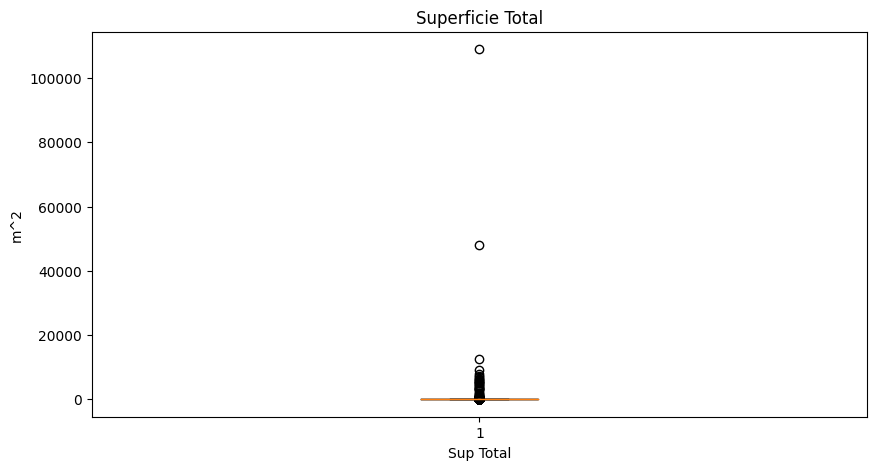

In [ ]:
#outliers sup total ()

plt.figure(figsize=(10, 5))  # Configurar el tamaño de la figura
plt.boxplot(df4['surface_total'])  # Crear el boxplot horizontal
plt.title('Superficie Total')  # Añadir el título del gráfico
plt.xlabel('Sup Total')  # Añadir la etiqueta del eje X
plt.ylabel('m^2')  # Etiqueta del eje Y

plt.show()  # Mostrar el boxplot

In [ ]:
# Calcular los cuartiles y el rango intercuartil (IQR)
Q1 = df4['surface_total'].quantile(0.65)
Q3 = df4['surface_total'].quantile(0.92)
IQR = Q3 - Q1

# Determinar los límites inferior y superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Límite inferior: {lower_bound}")
print(f"Límite superior: {upper_bound}")

# Identificar los outliers
outliers = df4[(df4['surface_total'] < lower_bound) | (df4['surface_total'] > upper_bound)]
print("\nOutliers:")
print(outliers)

Q1: 59.0
Q3: 91.0
IQR: 32.0
Límite inferior: 11.0
Límite superior: 139.0

Outliers:
          ad_type  start_date    end_date  created_on        lon        lat  \
id                                                                            
142348  Propiedad  2019-09-01  2019-09-04  2019-09-01 -58.422300 -34.590509   
387248  Propiedad  2019-12-16  2020-02-21  2019-12-16 -58.372069 -34.628719   
15920   Propiedad  2019-12-23  2020-01-18  2019-12-23 -58.512892 -34.661980   
54450   Propiedad  2019-07-20  2020-02-26  2019-07-20 -58.518238 -34.646695   
776242  Propiedad  2020-02-29  2020-04-01  2020-02-29 -58.486980 -34.662258   
...           ...         ...         ...         ...        ...        ...   
990342  Propiedad  2020-01-09  2020-08-21  2020-01-09 -58.475634 -34.570564   
992738  Propiedad  2020-01-09  2020-12-31  2020-01-09 -58.475634 -34.570564   
993933  Propiedad  2020-01-09  2020-01-16  2020-01-09 -58.492172 -34.581223   
994302  Propiedad  2020-01-09  2020-02-13  2020

In [ ]:
df4 = df4[(df4['surface_total'] >= 30) & (df4['surface_total'] <= 130)]

### surface_total vs surface_covered

---



In [ ]:
# Marcara donde superficie_total es menor que superficie_cubierta
mask = df4['surface_total'] < df4['surface_covered']

# Intercambiar los valores solo en las filas seleccionadas por la máscara
temp = df4.loc[mask, 'surface_total'].copy()
df4.loc[mask, 'surface_total'] = df4.loc[mask, 'surface_covered']
df4.loc[mask, 'surface_covered'] = temp

print("\nDataFrame con valores intercambiados en las filas seleccionadas:")
with pd.option_context('display.max_colwidth', None):
    print(df4)


DataFrame con valores intercambiados en las filas seleccionadas:
          ad_type  start_date    end_date  created_on        lon        lat  \
id                                                                            
556713  Propiedad  2019-11-29  2020-12-31  2019-11-29 -58.442399 -34.573623   
192912  Propiedad  2020-06-05  2020-06-08  2020-06-05 -58.430493 -34.606620   
238224  Propiedad  2020-07-01  2020-12-31  2020-07-01 -58.491760 -34.574123   
257134  Propiedad  2019-08-17  2020-12-31  2019-08-17 -58.420737 -34.631770   
521738  Propiedad  2019-08-05  2019-08-31  2019-08-05 -58.429983 -34.607225   
...           ...         ...         ...         ...        ...        ...   
998684  Propiedad  2020-01-09  2020-12-31  2020-01-09 -58.501139 -34.625848   
998685  Propiedad  2020-01-09  2020-12-31  2020-01-09 -58.501139 -34.625848   
998755  Propiedad  2020-01-09  2020-12-31  2020-01-09 -58.473996 -34.634941   
999237  Propiedad  2020-01-09  2020-02-13  2020-01-09 -58.433321 

In [ ]:
df4 = df4[(df4['surface_covered'] >= 20) & (df1['surface_covered'] <= 120)]

<ipython-input-291-abfef2c93b87>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df4 = df4[(df4['surface_covered'] >= 20) & (df1['surface_covered'] <= 120)]


In [ ]:
df4 = df4[(df4['surface_total'] >= 30) & (df4['surface_total'] <= 130)]

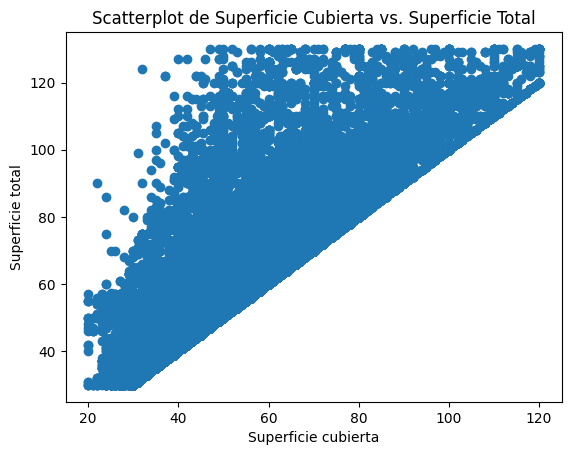

In [ ]:
# Gráfico de la relación entre sup Cubierta y Total
plt.scatter(df4['surface_covered'], df4['surface_total'])

plt.xlabel('Superficie cubierta')
plt.ylabel('Superficie total')
plt.title('Scatterplot de Superficie Cubierta vs. Superficie Total')

plt.show()

In [ ]:
# Se verifica que ya no hay sup total < sup cubierta

totalcoverd = df4[df4['surface_total'] < df4['surface_covered']]

print(totalcoverd)

Empty DataFrame
Columns: [ad_type, start_date, end_date, created_on, lon, lat, l2, l3, rooms, bedrooms, bathrooms, surface_total, surface_covered, currency, title, description, property_type, operation_type, price]
Index: []


In [ ]:
df4[df4['surface_covered'] < 20]

,ad_type,start_date,end_date,created_on,lon,lat,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,currency,title,description,property_type,operation_type,price
id,,,,,,,,,,,,,,,,,,,


In [ ]:
###
df4.shape

(74742, 19)

### MODELO 12

In [ ]:
df16 = df4.copy()

In [ ]:
df16.shape

(74742, 19)

In [ ]:
df16.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
dtype: int64

In [ ]:
df16.fillna(0, inplace=True)

In [ ]:
df16.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df16 = df16.select_dtypes(exclude=["object"])

In [ ]:
X = df16[df16.columns.drop("price")]
y = df16["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

122640.89997055886

###bedrooms

In [ ]:
# Intevalos variable bedrooms
bins = [0, 1, 2, 3, 5, 10, 11, 15, 1000]

bedrooms_bins = pd.cut(df4['bedrooms'], bins=bins)

frecuencia_bedrooms_bins = bedrooms_bins.value_counts().sort_index()

print("Frecuencia de bedrooms por bins:")
print(frecuencia_bedrooms_bins)

Frecuencia de bedrooms por bins:
bedrooms
(0, 1]        50235
(1, 2]        24339
(2, 3]          168
(3, 5]            0
(5, 10]           0
(10, 11]          0
(11, 15]          0
(15, 1000]        0
Name: count, dtype: int64


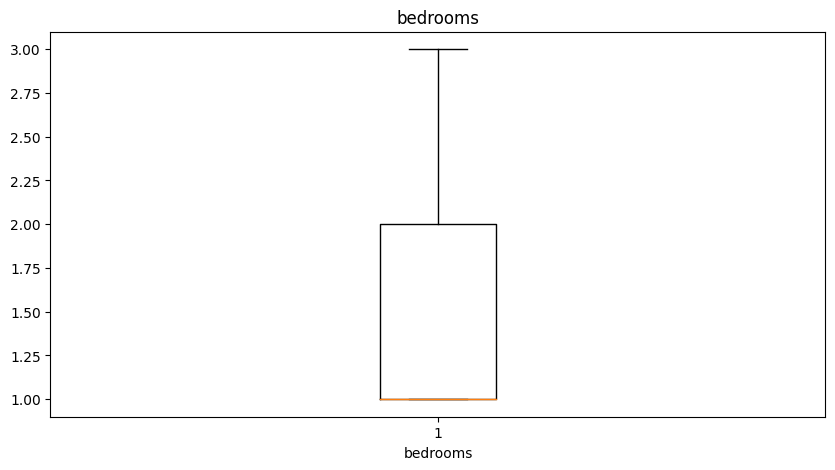

In [ ]:
# outliers bedrooms()

plt.figure(figsize=(10, 5))
plt.boxplot(df4['bedrooms'])
plt.title('bedrooms')
plt.xlabel('bedrooms')


plt.show()  # Mostrar el boxplot

In [ ]:
###
df4.shape

(74742, 19)

In [ ]:
df4= df4.loc[df4['bathrooms'] <= 2]
print(df4['bathrooms'].value_counts())

bathrooms
1.0    61682
2.0    12186
Name: count, dtype: int64


### bathrooms

In [ ]:
# Intevalos variablevariable bathrooms
bins = [0, 1, 2, 3, 5, 10, 11, 15, 10000000]

bathrooms_bins = pd.cut(df4['bathrooms'], bins=bins)

frecuencia_bathrooms_bins = bathrooms_bins.value_counts().sort_index()

print("Frecuencia de bathrooms por bins:")
print(frecuencia_bathrooms_bins)

Frecuencia de bathrooms por bins:
bathrooms
(0, 1]            61682
(1, 2]            12186
(2, 3]                0
(3, 5]                0
(5, 10]               0
(10, 11]              0
(11, 15]              0
(15, 10000000]        0
Name: count, dtype: int64


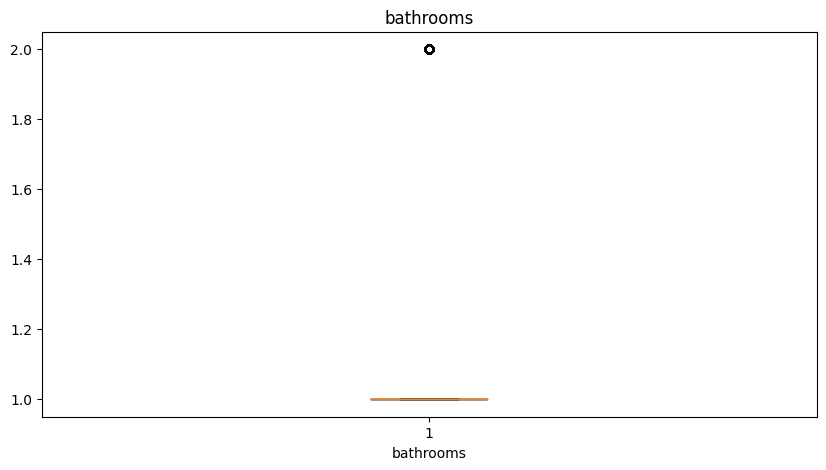

In [ ]:
# outliers bathrooms()

plt.figure(figsize=(10, 5))
plt.boxplot(df4['bathrooms'])
plt.title('bathrooms')
plt.xlabel('bathrooms')

plt.show()

In [ ]:
df4= df4.loc[df4['bathrooms'] <= 2]
print(df4['bathrooms'].value_counts())

bathrooms
1.0    61682
2.0    12186
Name: count, dtype: int64


### bedrooms vs bathrooms

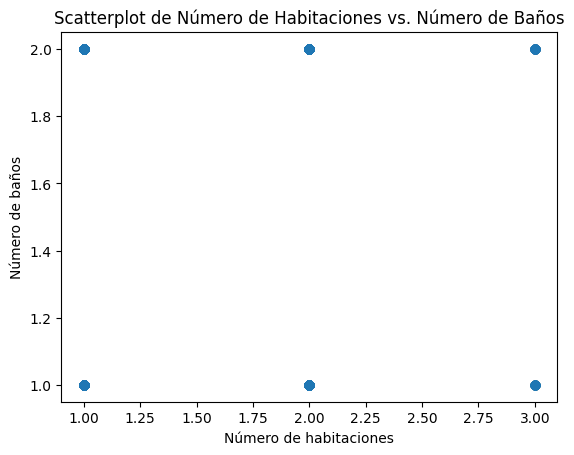

In [ ]:
# Relación entre Habitaciones y Baños
plt.scatter(df4['bedrooms'], df4['bathrooms'])

plt.xlabel('Número de habitaciones')
plt.ylabel('Número de baños')
plt.title('Scatterplot de Número de Habitaciones vs. Número de Baños')

plt.show()

In [ ]:
df4.shape

(73868, 19)

### MODELO 13

In [ ]:
df17 = df4.copy()

In [ ]:
df17.shape

(73868, 19)

In [ ]:
df17.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
dtype: int64

In [ ]:
df17.fillna(0, inplace=True)

In [ ]:
df17.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df17 = df17.select_dtypes(exclude=["object"])

In [ ]:
X = df17[df17.columns.drop("price")]
y = df17["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

89203.08274500784

### Price




In [ ]:
# Intervalos variable price
bins = [-10000000, 0, 20000, 40000, 50000, 100000, 150000, 200000, 250000, 300000, 350000, 400000, 450000, 500000, 683000, 750000, 850000, 1000000, 1250000,1500000, 2000000, 3000000, 4000000, 5000000, 10000000, 50000000, 600000000]

price_bins = pd.cut(df4['price'], bins=bins)

frecuencia_price_bins = price_bins.value_counts().sort_index()

print("Frecuencia de price por bins:")
print(frecuencia_price_bins)

Frecuencia de price por bins:
price
(-10000000, 0]               0
(0, 20000]                  47
(20000, 40000]              59
(40000, 50000]             218
(50000, 100000]          17169
(100000, 150000]         26696
(150000, 200000]         15566
(200000, 250000]          7435
(250000, 300000]          3561
(300000, 350000]          1534
(350000, 400000]           672
(400000, 450000]           301
(450000, 500000]           212
(500000, 683000]           313
(683000, 750000]            33
(750000, 850000]            13
(850000, 1000000]           10
(1000000, 1250000]          12
(1250000, 1500000]           1
(1500000, 2000000]           1
(2000000, 3000000]           0
(3000000, 4000000]           2
(4000000, 5000000]           0
(5000000, 10000000]          9
(10000000, 50000000]         4
(50000000, 600000000]        0
Name: count, dtype: int64


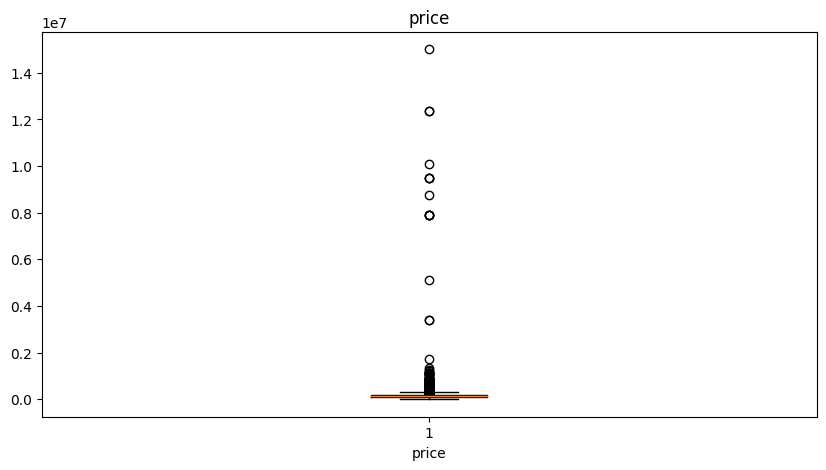

In [ ]:
# outliers price()

plt.figure(figsize=(10, 5))
plt.boxplot(df4['price'])
plt.title('price')
plt.xlabel('price')


plt.show()

In [ ]:
# Crear una máscara booleana para las filas donde 'price' está entre 30000 y 300000
mask = (df4['price'] >= 30000) & (df4['price'] <= 300000)

df4 = df4[mask]

print(df4['price'].describe())

count     70696.000000
mean     144164.926686
std       54482.457626
min       30000.000000
25%      101882.352941
50%      134000.000000
75%      177000.000000
max      300000.000000
Name: price, dtype: float64


In [ ]:
# precio por metro cuadrado
df4['price_per_sqm'] = df4['price'] / df4['surface_total']

print(df4[['price', 'surface_total', 'price_per_sqm']])


           price  surface_total  price_per_sqm
id                                            
556713  259000.0           48.0    5395.833333
192912  235500.0           77.0    3058.441558
238224  175000.0           60.0    2916.666667
257134  140000.0           74.0    1891.891892
521738  173000.0           66.0    2621.212121
...          ...            ...            ...
997850  260000.0           89.0    2921.348315
997864  160000.0           61.0    2622.950820
998684  245000.0           96.0    2552.083333
998685  245000.0           96.0    2552.083333
998755  170000.0           74.0    2297.297297

[70696 rows x 3 columns]


<ipython-input-332-88483c458605>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['price_per_sqm'] = df4['price'] / df4['surface_total']


### MODELO 14

In [ ]:
df18 = df4.copy()

In [ ]:
df18.shape

(70696, 20)

In [ ]:
df18.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
price_per_sqm      0
dtype: int64

In [ ]:
df18.fillna(0, inplace=True)

In [ ]:
df18.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
price_per_sqm      float64
dtype: object

In [ ]:
df18 = df18.select_dtypes(exclude=["object"])

In [ ]:
X = df18[df18.columns.drop("price")]
y = df18["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

27412.070507040324

### Precio m2 x sup total x l3 (mediana)

In [ ]:
# Precio por metro cuadrado por cada barrio por superficie
precio_por_m2_por_barrio = df4.groupby('l3')['price'].sum() / df4.groupby('l3')['surface_total'].sum()

df4['precio_por_m2'] = df4['l3'].map(precio_por_m2_por_barrio)

df4['precio_ajustado'] = df4['precio_por_m2'] * df4['surface_total']

print("Resultados completos:")
print(df4[['l3', 'price', 'surface_total', 'precio_por_m2', 'precio_ajustado']])

Resultados completos:
                       l3     price  surface_total  precio_por_m2  \
id                                                                  
556713         Colegiales  259000.0           48.0    2725.350577   
192912            Almagro  235500.0           77.0    2571.138170   
238224      Villa Urquiza  175000.0           60.0    2679.216954   
257134              Boedo  140000.0           74.0    2212.832041   
521738            Almagro  173000.0           66.0    2571.138170   
...                   ...       ...            ...            ...   
997850          Caballito  260000.0           89.0    2612.869334   
997864  Parque Centenario  160000.0           61.0    2458.540980   
998684           Floresta  245000.0           96.0    1911.077088   
998685           Floresta  245000.0           96.0    1911.077088   
998755           Floresta  170000.0           74.0    1911.077088   

        precio_ajustado  
id                       
556713    130816.827714  
19

In [ ]:
df4.precio_ajustado

id
556713    130816.827714
192912    197977.639110
238224    160753.017231
257134    163749.571064
521738    169695.119237
              ...      
997850    232545.370682
997864    149970.999775
998684    183463.400404
998685    183463.400404
998755    141419.704478
Name: precio_ajustado, Length: 70696, dtype: float64

In [ ]:
df4.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
price_per_sqm      0
precio_por_m2      0
precio_ajustado    0
dtype: int64

In [ ]:
df4 = df4.drop(columns=['price_per_sqm', 'price_per_sqm_covered', 'precio_por_m2', 'precio_por_m2_mediana', 'diferencia_precio_real_ajustado', 'diferencia'])

In [ ]:
# Se calculan outliers con el nuevo precio
df4['diferencia_precio_real_ajustado'] = df4['price'] - df4['precio_ajustado']

std_dev = df4['diferencia_precio_real_ajustado'].std()
mean_diff = df4['diferencia_precio_real_ajustado'].mean()

outliers = df4[df4['diferencia_precio_real_ajustado'].abs() > 3 * std_dev]


numero_observaciones = outliers.shape[0]

print(f"Número de observaciones que son outliers: {numero_observaciones}")


Número de observaciones que son outliers: 1107


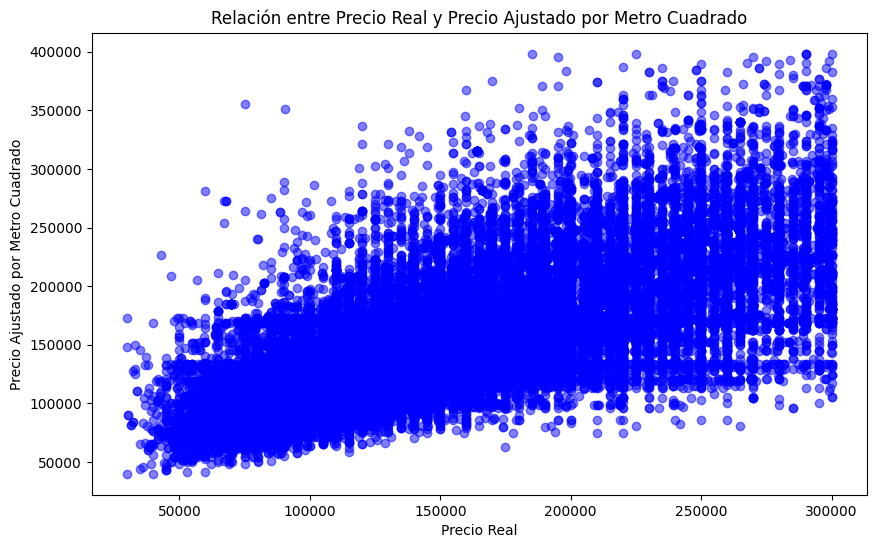

In [ ]:
# Se crean figuras y ejes
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df4['price'], df4['precio_ajustado'], alpha=0.5, color='blue')

ax.set_xlabel('Precio Real')
ax.set_ylabel('Precio Ajustado por Metro Cuadrado')
ax.set_title('Relación entre Precio Real y Precio Ajustado por Metro Cuadrado')

plt.show()

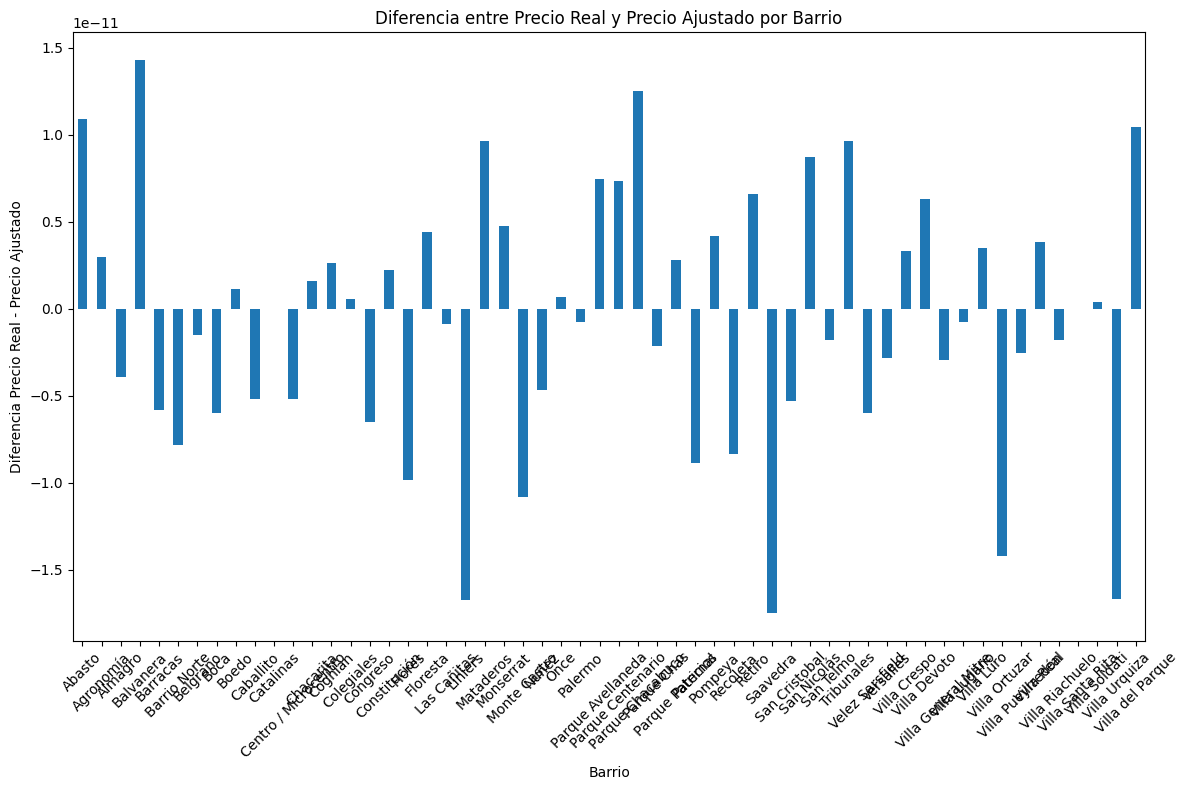

In [ ]:
df4['diferencia'] = df4['price'] - df4['precio_ajustado']

fig, ax = plt.subplots(figsize=(12, 8))
df4.groupby('l3')['diferencia'].mean().plot(kind='bar', ax=ax)

ax.set_xlabel('Barrio')
ax.set_ylabel('Diferencia Precio Real - Precio Ajustado')
ax.set_title('Diferencia entre Precio Real y Precio Ajustado por Barrio')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Se eliminan las filas que son outliers basado en el criterio anterior
df4.drop(outliers.index, inplace=True)

numero_eliminadas = outliers.shape[0]
print(f"Número de observaciones eliminadas: {numero_eliminadas}")

Número de observaciones eliminadas: 1107


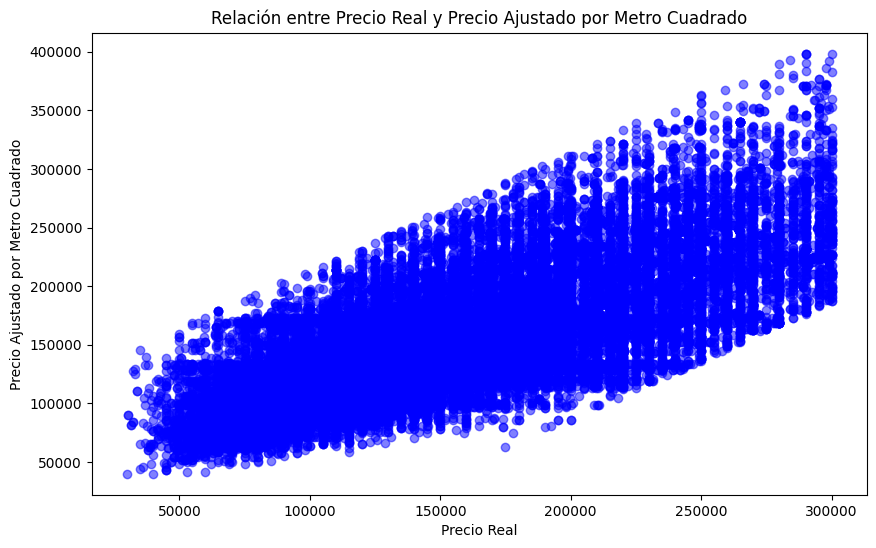

In [ ]:
# Gráfico con el nuevo ajuste
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df4['price'], df4['precio_ajustado'], alpha=0.5, color='blue')

ax.set_xlabel('Precio Real')
ax.set_ylabel('Precio Ajustado por Metro Cuadrado')
ax.set_title('Relación entre Precio Real y Precio Ajustado por Metro Cuadrado')

plt.show()

In [ ]:
# Calcular diferencias o ratios para identificar outliers
df4['diferencia_precio_real_ajustado'] = df4['price'] - df4['precio_ajustado']

std_dev = df4['diferencia_precio_real_ajustado'].std()
mean_diff = df4['diferencia_precio_real_ajustado'].mean()

outliers = df4[df4['diferencia_precio_real_ajustado'].abs() > 1.5 * std_dev]

numero_observaciones = outliers.shape[0]

print(f"Número de observaciones que son outliers: {numero_observaciones}")

Número de observaciones que son outliers: 9295


In [ ]:
# Eliminar las filas que son outliers basado en el criterio anterior
df4.drop(outliers.index, inplace=True)

# Mostrar el número de observaciones eliminadas
numero_eliminadas = outliers.shape[0]
print(f"Número de observaciones eliminadas: {numero_eliminadas}")

Número de observaciones eliminadas: 9295


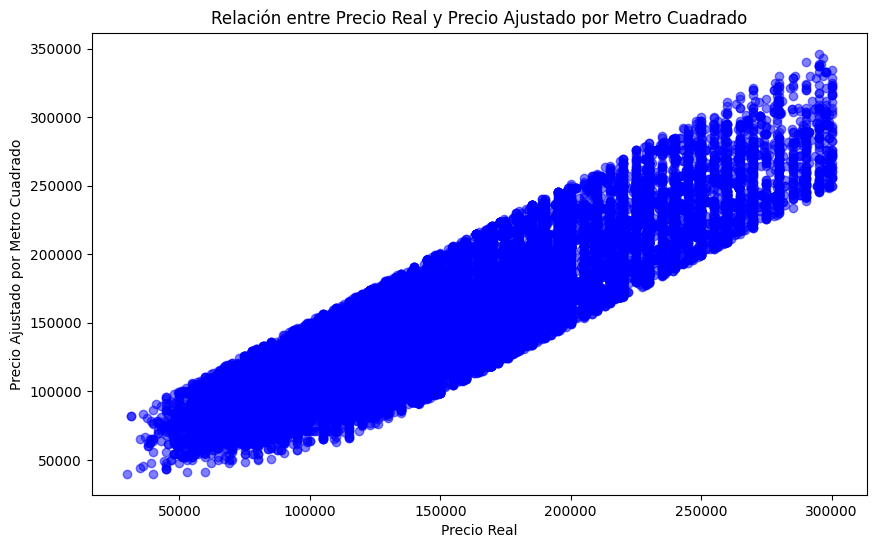

In [ ]:
# Gráfico con el nuevo ajuste
fig, ax = plt.subplots(figsize=(10, 6))

# Graficar precio real vs. precio ajustado por metro cuadrado
ax.scatter(df4['price'], df4['precio_ajustado'], alpha=0.5, color='blue')

# Etiquetas y título
ax.set_xlabel('Precio Real')
ax.set_ylabel('Precio Ajustado por Metro Cuadrado')
ax.set_title('Relación entre Precio Real y Precio Ajustado por Metro Cuadrado')

# Mostrar la gráfica
plt.show()

In [ ]:
# Calcular diferencias o ratios para identificar outliers
df4['diferencia_precio_real_ajustado'] = df4['price'] - df4['precio_ajustado']

std_dev = df4['diferencia_precio_real_ajustado'].std()
mean_diff = df4['diferencia_precio_real_ajustado'].mean()

outliers = df4[df4['diferencia_precio_real_ajustado'].abs() > 1.4 * std_dev]

numero_observaciones = outliers.shape[0]

print(f"Número de observaciones que son outliers: {numero_observaciones}")

Número de observaciones que son outliers: 11273


In [ ]:
# Eliminar las filas que son outliers basado en el criterio anterior
df4.drop(outliers.index, inplace=True)

# Mostrar el número de observaciones eliminadas
numero_eliminadas = outliers.shape[0]
print(f"Número de observaciones eliminadas: {numero_eliminadas}")

Número de observaciones eliminadas: 11273


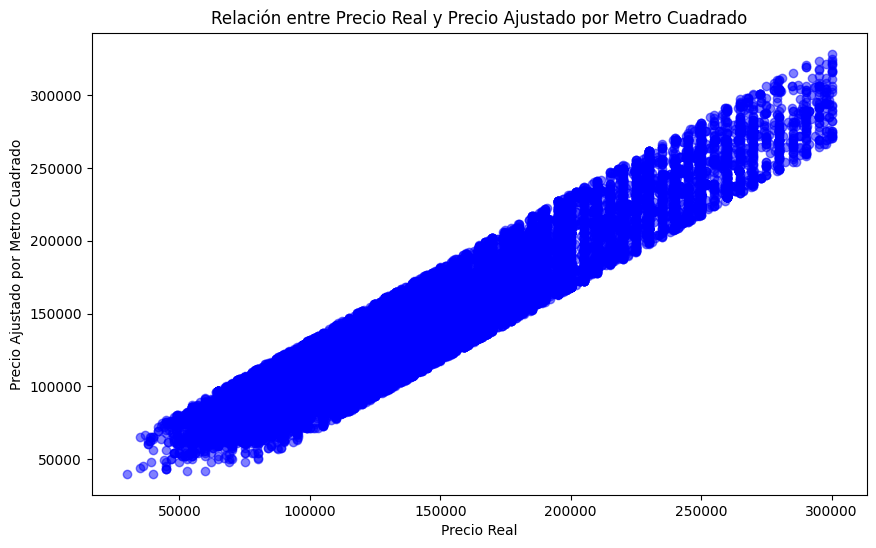

In [ ]:
# Gráfico con el nuevo ajuste
fig, ax = plt.subplots(figsize=(10, 6))

# Graficar precio real vs. precio ajustado por metro cuadrado
ax.scatter(df4['price'], df4['precio_ajustado'], alpha=0.5, color='blue')

# Etiquetas y título
ax.set_xlabel('Precio Real')
ax.set_ylabel('Precio Ajustado por Metro Cuadrado')
ax.set_title('Relación entre Precio Real y Precio Ajustado por Metro Cuadrado')

# Mostrar la gráfica
plt.show()

In [ ]:
df4.isna().sum()

ad_type                            0
start_date                         0
end_date                           0
created_on                         0
lon                                0
lat                                0
l2                                 0
l3                                 0
rooms                              0
bedrooms                           0
bathrooms                          0
surface_total                      0
surface_covered                    0
currency                           0
title                              0
description                        0
property_type                      0
operation_type                     0
price                              0
price_per_sqm                      0
precio_por_m2                      0
precio_ajustado                    0
diferencia_precio_real_ajustado    0
diferencia                         0
dtype: int64

In [ ]:
df4.drop(columns=['diferencia_precio_real_ajustado', 'precio_por_m2', 'diferencia', 'price_per_sqm'], inplace=True)

### MODELO 15

In [ ]:
df19 = df4.copy()

In [ ]:
df19.shape

(49021, 20)

In [ ]:
df19.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
precio_ajustado    0
dtype: int64

In [ ]:
df19.fillna(0, inplace=True)

In [ ]:
df19.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
precio_ajustado    float64
dtype: object

In [ ]:
df19 = df19.select_dtypes(exclude=["object"])

In [ ]:
X = df19[df19.columns.drop("price")]
y = df19["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

17203.58506256972

[Text(0.5, 0.875, 'precio_ajustado <= 145952.93\nfriedman_mse = 2136299484.972\nsamples = 39216\nvalue = 132597.534'),
 Text(0.25, 0.625, 'precio_ajustado <= 105311.344\nfriedman_mse = 602039902.621\nsamples = 26893\nvalue = 108508.714'),
 Text(0.125, 0.375, 'precio_ajustado <= 88035.0\nfriedman_mse = 310659552.996\nsamples = 12265\nvalue = 91087.756'),
 Text(0.0625, 0.125, 'friedman_mse = 202098407.674\nsamples = 4687\nvalue = 80252.709'),
 Text(0.1875, 0.125, 'friedman_mse = 260283869.295\nsamples = 7578\nvalue = 97789.243'),
 Text(0.375, 0.375, 'precio_ajustado <= 125277.703\nfriedman_mse = 378528488.061\nsamples = 14628\nvalue = 123115.498'),
 Text(0.3125, 0.125, 'friedman_mse = 278752891.076\nsamples = 8181\nvalue = 114617.377'),
 Text(0.4375, 0.125, 'friedman_mse = 297207701.073\nsamples = 6447\nvalue = 133899.294'),
 Text(0.75, 0.625, 'precio_ajustado <= 207784.039\nfriedman_mse = 1454618708.352\nsamples = 12323\nvalue = 185167.578'),
 Text(0.625, 0.375, 'precio_ajustado <= 1777

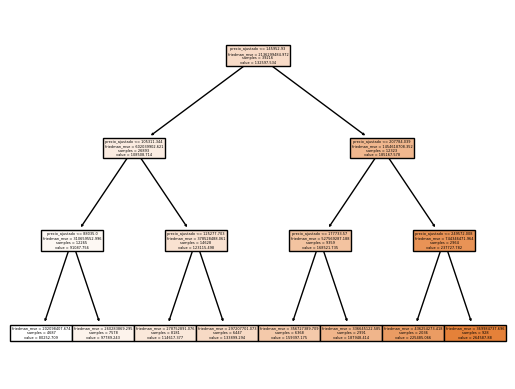

In [ ]:
# Visualización de como el modelo toma las decisiones
sk.tree.plot_tree(reg, feature_names=X_train.columns, filled=True)

In [ ]:
# Exportación del checkpoint limpio del resto de CABA.
df4.to_csv(DATA_DIR / "df4_limpio.csv.gz", index=False, compression="gzip")

*Se observa una mejora notable en el tratamiento de los outliers para los barrios de Capital Federal, ya que de un RMSE DE 162.479 en el modelo 11, se paso a uno de 17.203 en el modelo 15*

## 3.2.2 - Puerto Madero - df3

### MODELO 16

In [ ]:
df22 = df3.copy()

In [ ]:
df22.shape

(1151, 19)

In [ ]:
df22.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
dtype: int64

In [ ]:
df22.fillna(0, inplace=True)

In [ ]:
df22.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
dtype: object

In [ ]:
df22 = df22.select_dtypes(exclude=["object"])

In [ ]:
X = df22[df22.columns.drop("price")]
y = df22["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

228366.4404272836

[Text(0.5, 0.875, 'surface_total <= 127.5\nfriedman_mse = 137646249095.059\nsamples = 920\nvalue = 599097.997'),
 Text(0.25, 0.625, 'surface_total <= 73.5\nfriedman_mse = 60632394050.963\nsamples = 717\nvalue = 470230.656'),
 Text(0.125, 0.375, 'surface_covered <= 47.5\nfriedman_mse = 11160785311.614\nsamples = 311\nvalue = 302913.468'),
 Text(0.0625, 0.125, 'friedman_mse = 5548238214.046\nsamples = 101\nvalue = 194902.076'),
 Text(0.1875, 0.125, 'friedman_mse = 5550511379.395\nsamples = 210\nvalue = 354861.805'),
 Text(0.375, 0.375, 'bathrooms <= 2.5\nfriedman_mse = 60656975122.03\nsamples = 406\nvalue = 598397.271'),
 Text(0.3125, 0.125, 'friedman_mse = 42458965073.976\nsamples = 326\nvalue = 553257.702'),
 Text(0.4375, 0.125, 'friedman_mse = 92675424888.112\nsamples = 80\nvalue = 782341.012'),
 Text(0.75, 0.625, 'surface_covered <= 195.0\nfriedman_mse = 143832755304.237\nsamples = 203\nvalue = 1054259.982'),
 Text(0.625, 0.375, 'lon <= -58.361\nfriedman_mse = 87566468020.126\nsample

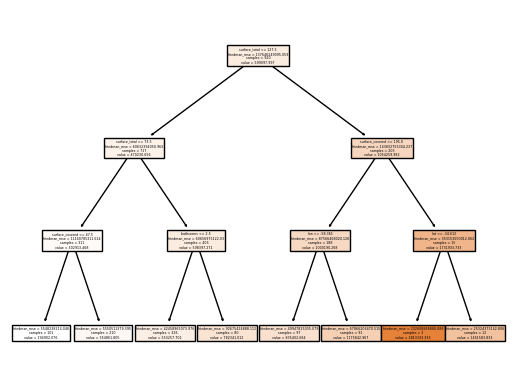

In [ ]:
# Visualización de como el modelo toma las decisiones
sk.tree.plot_tree(reg, feature_names=X_train.columns, filled=True)

***Se observa una mejora notable en el valor del RMSE en los barrios de Capital Federal, ya que de 228.366 en el modelo 16 se paso a un RMSE de 17.203 en el modelo 15***

### surface_covered

In [ ]:
# Estadísticas descriptivas para surface_covered
estadisticas_por_tipo = df3.groupby('surface_covered').describe()
print("\nEstadísticas descriptivas de surface_covered por tipo de operación:")
print(estadisticas_por_tipo)


Estadísticas descriptivas de surface_covered por tipo de operación:
                  lon                                                        \
                count       mean       std        min        25%        50%   
surface_covered                                                               
24.0              7.0 -58.361703  0.000294 -58.362069 -58.361979 -58.361489   
27.0              9.0 -58.367999  0.000066 -58.368067 -58.368067 -58.367964   
28.0              7.0 -58.367913  0.000092 -58.368067 -58.367931 -58.367931   
30.0              7.0 -58.367204  0.001336 -58.368067 -58.367999 -58.367931   
32.0              1.0 -58.367931       NaN -58.367931 -58.367931 -58.367931   
...               ...        ...       ...        ...        ...        ...   
213.0             1.0 -58.363594       NaN -58.363594 -58.363594 -58.363594   
220.0             1.0 -58.362588       NaN -58.362588 -58.362588 -58.362588   
250.0             1.0 -58.359653       NaN -58.359653 -58.3596

In [ ]:
df3.shape

(1151, 19)

In [ ]:
# Definir los intervalos (bins) para la variable surface_covered
bins = [0, 10, 20, 50, 80, 100, 120, 150, 175, 250, 500, 1000, 10000, 20000, 30000, 100000, 1000000]

# Crear los bins para la variable surface_covered
surface_covered_bins = pd.cut(df3['surface_covered'], bins=bins)

# Contar la frecuencia de valores en cada bin
frecuencia_surface_covered_bins = surface_covered_bins.value_counts().sort_index()

# Imprimir la frecuencia de surface_covered por bins
print("Frecuencia de surface_covered por bins:")
print(frecuencia_surface_covered_bins)

Frecuencia de surface_covered por bins:
surface_covered
(0, 10]                0
(10, 20]               0
(20, 50]             149
(50, 80]             358
(80, 100]            284
(100, 120]           133
(120, 150]           124
(150, 175]             0
(175, 250]             0
(250, 500]             0
(500, 1000]            0
(1000, 10000]          0
(10000, 20000]         0
(20000, 30000]         0
(30000, 100000]        0
(100000, 1000000]      0
Name: count, dtype: int64


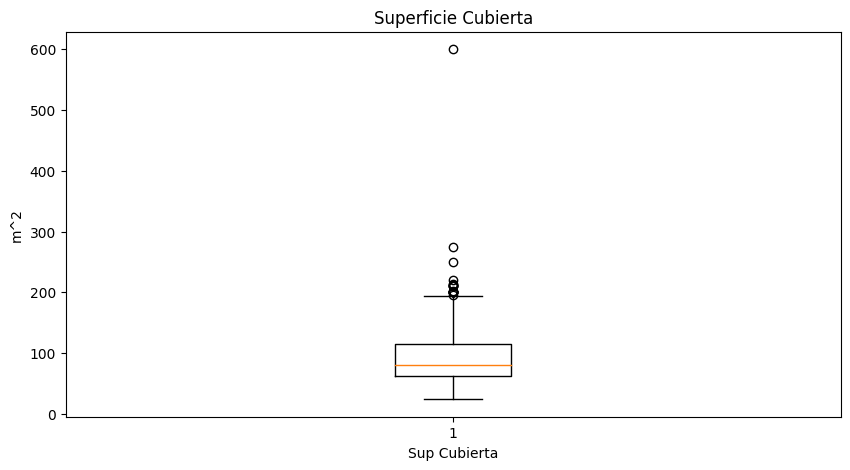

In [ ]:
#outliers sup cubierta ()

plt.figure(figsize=(10, 5))  # Configurar el tamaño de la figura
plt.boxplot(df3['surface_covered'])  # Crear el boxplot horizontal
plt.title('Superficie Cubierta')  # Añadir el título del gráfico
plt.xlabel('Sup Cubierta')  # Añadir la etiqueta del eje X
plt.ylabel('m^2')  # Etiqueta del eje Y

plt.show()  # Mostrar el boxplot


In [ ]:
df3 = df3[(df3['surface_covered'] >= 20) & (df3['surface_covered'] <= 150)]

### surface_total

In [ ]:
# Definir los intervalos (bins) para la variable surface_total
bins = [0, 10, 20, 50, 80, 100, 120, 150, 221, 250, 500, 1000, 10000, 20000, 30000, 100000, 1000000, 2000000]

# Crear los bins para la variable surface_total
surface_total_bins = pd.cut(df3['surface_total'], bins=bins)

# Contar la frecuencia de valores en cada bin
frecuencia_surface_total_bins = surface_total_bins.value_counts().sort_index()

# Imprimir la frecuencia de surface_total por bins
print("Frecuencia de surface_total por bins:")
print(frecuencia_surface_total_bins)

Frecuencia de surface_total por bins:
surface_total
(0, 10]                 0
(10, 20]                0
(20, 50]              103
(50, 80]              328
(80, 100]             275
(100, 120]            131
(120, 150]            143
(150, 221]              8
(221, 250]              0
(250, 500]              0
(500, 1000]             0
(1000, 10000]           0
(10000, 20000]          0
(20000, 30000]          0
(30000, 100000]         0
(100000, 1000000]       0
(1000000, 2000000]      0
Name: count, dtype: int64


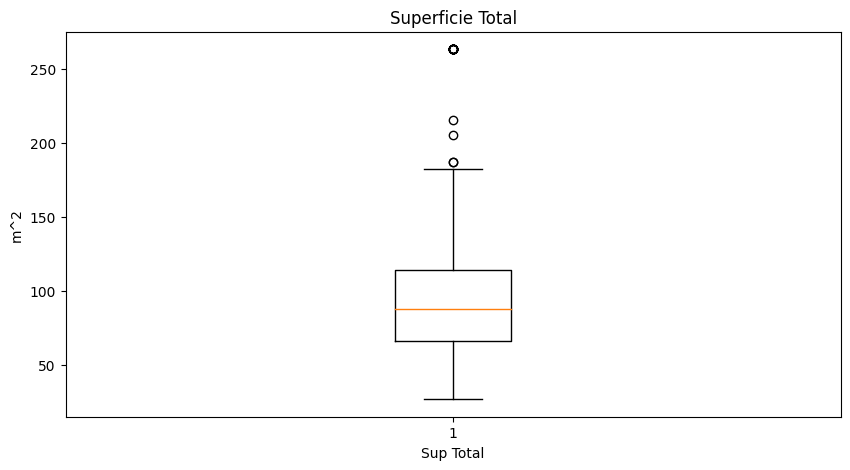

In [ ]:
#outliers sup total ()

plt.figure(figsize=(10, 5))  # Configurar el tamaño de la figura
plt.boxplot(df3['surface_total'])  # Crear el boxplot horizontal
plt.title('Superficie Total')  # Añadir el título del gráfico
plt.xlabel('Sup Total')  # Añadir la etiqueta del eje X
plt.ylabel('m^2')  # Etiqueta del eje Y

plt.show()  # Mostrar el boxplot

In [ ]:
df3 = df3[(df3['surface_total'] >= 30) & (df3['surface_total'] <= 160)]

### surface_total vs surface_covered

---



In [ ]:
# Crear una máscara para las filas donde superficie_total es menor que superficie_cubierta
mask = df3['surface_total'] < df3['surface_covered']

# Usar una variable temporal para intercambiar los valores solo en las filas seleccionadas por la máscara
temp = df3.loc[mask, 'surface_total'].copy()
df3.loc[mask, 'surface_total'] = df3.loc[mask, 'surface_covered']
df3.loc[mask, 'surface_covered'] = temp

# Mostrar el DataFrame con los valores intercambiados solo en las filas seleccionadas
print("\nDataFrame con valores intercambiados en las filas seleccionadas:")
with pd.option_context('display.max_colwidth', None):
    print(df3)


DataFrame con valores intercambiados en las filas seleccionadas:
          ad_type  start_date    end_date  created_on        lon        lat  \
id                                                                            
987469  Propiedad  2019-08-01  2019-08-14  2019-08-01 -58.363135 -34.611594   
364006  Propiedad  2020-02-09  2020-02-20  2020-02-09 -58.360130 -34.613297   
952540  Propiedad  2020-04-23  2020-05-03  2020-04-23 -58.360466 -34.619165   
849850  Propiedad  2020-02-03  2020-09-03  2020-02-03 -58.361799 -34.617055   
391593  Propiedad  2020-01-05  2020-02-11  2020-01-05 -58.361305 -34.617384   
...           ...         ...         ...         ...        ...        ...   
993633  Propiedad  2020-01-09  2020-07-13  2020-01-09 -58.363135 -34.611594   
994327  Propiedad  2020-01-09  2020-02-13  2020-01-09 -58.363135 -34.611594   
994328  Propiedad  2020-01-09  2020-02-13  2020-01-09 -58.363135 -34.611594   
994329  Propiedad  2020-01-09  2020-02-13  2020-01-09 -58.362672 

In [ ]:
df3 = df3[(df3['surface_covered'] >= 20) & (df1['surface_covered'] <= 150)]

<ipython-input-541-d18642e6ff29>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df3 = df3[(df3['surface_covered'] >= 20) & (df1['surface_covered'] <= 150)]


In [ ]:
df3 = df3[(df3['surface_total'] >= 30) & (df3['surface_total'] <= 160)]

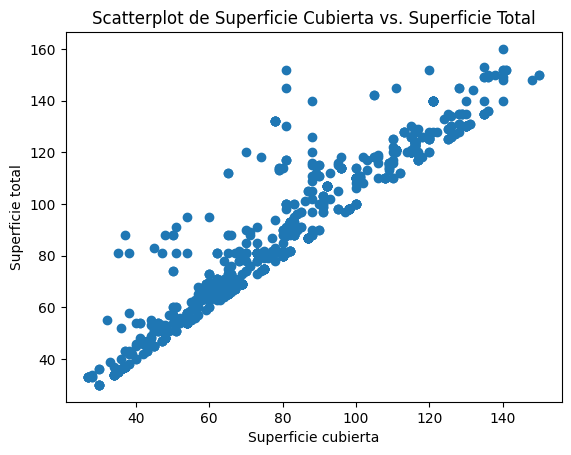

In [ ]:
# Gráfico de la relación entre sup Cubierta y Total
plt.scatter(df3['surface_covered'], df3['surface_total'])

plt.xlabel('Superficie cubierta')
plt.ylabel('Superficie total')
plt.title('Scatterplot de Superficie Cubierta vs. Superficie Total')

plt.show()

### bedrooms

In [ ]:
# Definir los intervalos (bins) para la variable bedrooms
bins = [0, 1, 2, 3, 5, 10, 11, 15, 1000]

# Crear los bins para la variable bedrooms
bedrooms_bins = pd.cut(df3['bedrooms'], bins=bins)

# Contar la frecuencia de valores en cada bin
frecuencia_bedrooms_bins = bedrooms_bins.value_counts().sort_index()

# Imprimir la frecuencia de bedrooms por bins
print("Frecuencia de bedrooms por bins:")
print(frecuencia_bedrooms_bins)

Frecuencia de bedrooms por bins:
bedrooms
(0, 1]        456
(1, 2]        531
(2, 3]          1
(3, 5]          0
(5, 10]         0
(10, 11]        0
(11, 15]        0
(15, 1000]      0
Name: count, dtype: int64


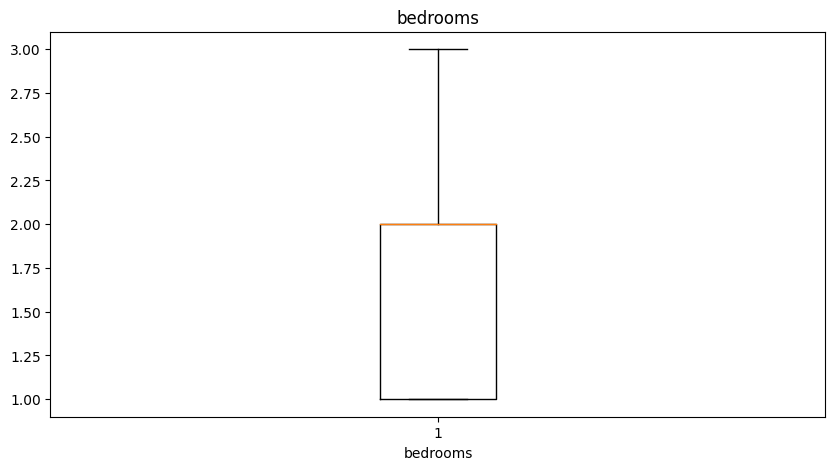

In [ ]:
# outliers bedrooms()

plt.figure(figsize=(10, 5))  # Configurar el tamaño de la figura
plt.boxplot(df3['bedrooms'])  # Crear el boxplot horizontal
plt.title('bedrooms')  # Añadir el título del gráfico
plt.xlabel('bedrooms')  # Añadir la etiqueta del eje X


plt.show()  # Mostrar el boxplot

In [ ]:
df3= df3.loc[df3['bathrooms'] <= 3]
print(df3['bathrooms'].value_counts())

bathrooms
2.0    462
1.0    369
3.0    157
Name: count, dtype: int64


### bathrooms

In [ ]:
# Definir los intervalos (bins) para la variable bathrooms
bins = [0, 1, 2, 3, 5, 10, 11, 15, 10000000]

# Crear los bins para la variable bathrooms
bathrooms_bins = pd.cut(df3['bathrooms'], bins=bins)

# Contar la frecuencia de valores en cada bin
frecuencia_bathrooms_bins = bathrooms_bins.value_counts().sort_index()

# Imprimir la frecuencia de bathrooms por bins
print("Frecuencia de bathrooms por bins:")
print(frecuencia_bathrooms_bins)

Frecuencia de bathrooms por bins:
bathrooms
(0, 1]            369
(1, 2]            462
(2, 3]            157
(3, 5]              0
(5, 10]             0
(10, 11]            0
(11, 15]            0
(15, 10000000]      0
Name: count, dtype: int64


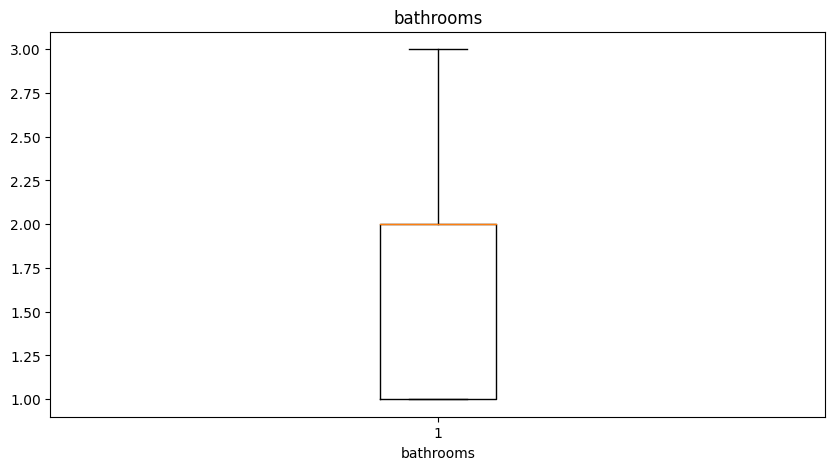

In [ ]:
# outliers bathrooms()

plt.figure(figsize=(10, 5))  # Configurar el tamaño de la figura
plt.boxplot(df3['bathrooms'])  # Crear el boxplot horizontal
plt.title('bathrooms')  # Añadir el título del gráfico
plt.xlabel('bathrooms')  # Añadir la etiqueta del eje X


plt.show()  # Mostrar el boxplot

In [ ]:
df3= df3.loc[df3['bathrooms'] <= 3]
print(df3['bathrooms'].value_counts())

bathrooms
2.0    462
1.0    369
3.0    157
Name: count, dtype: int64


### bedrooms vs bathrooms

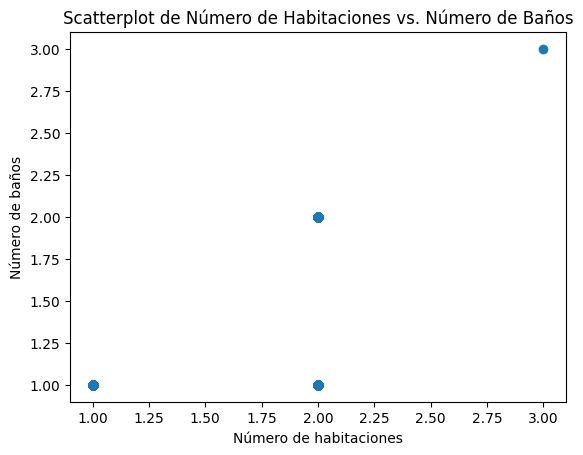

In [ ]:
# Crear el scatterplot
plt.scatter(df3['bedrooms'], df3['bathrooms'])

# Agregar etiquetas y título
plt.xlabel('Número de habitaciones')
plt.ylabel('Número de baños')
plt.title('Scatterplot de Número de Habitaciones vs. Número de Baños')

# Mostrar el plot
plt.show()

In [ ]:
# Verificar si bathrooms es mayor que bedrooms
df3['bathrooms_greater_than_bedrooms'] = df3['bathrooms'] > df3['bedrooms']

df3 = df3[df3['bathrooms_greater_than_bedrooms'] == False]
print(df3[['bathrooms', 'bedrooms', 'bathrooms_greater_than_bedrooms']])


        bathrooms  bedrooms  bathrooms_greater_than_bedrooms
id                                                          
364006        2.0       2.0                            False
952540        2.0       2.0                            False
849850        1.0       1.0                            False
391593        1.0       2.0                            False
10500         1.0       2.0                            False
...           ...       ...                              ...
987510        2.0       2.0                            False
993633        1.0       2.0                            False
994327        1.0       1.0                            False
994328        1.0       1.0                            False
994329        1.0       1.0                            False

[607 rows x 3 columns]


### Price

In [ ]:
# Definir los intervalos (bins) para la variable price
bins = [0, 50000, 100000, 150000, 200000, 250000, 300000, 350000, 400000, 450000, 500000, 683000, 750000, 850000, 1000000, 1250000,1500000, 2000000, 3000000, 4000000, 5000000, 10000000, 50000000, 600000000]

# Crear los bins para la variable price
price_bins = pd.cut(df3['price'], bins=bins)

# Contar la frecuencia de valores en cada bin
frecuencia_price_bins = price_bins.value_counts().sort_index()

# Imprimir la frecuencia de price por bins
print("Frecuencia de price por bins:")
print(frecuencia_price_bins)

Frecuencia de price por bins:
price
(0, 50000]                 0
(50000, 100000]           20
(100000, 150000]          15
(150000, 200000]           9
(200000, 250000]          51
(250000, 300000]          85
(300000, 350000]          81
(350000, 400000]          55
(400000, 450000]          52
(450000, 500000]          30
(500000, 683000]         114
(683000, 750000]          40
(750000, 850000]           0
(850000, 1000000]          0
(1000000, 1250000]         0
(1250000, 1500000]         0
(1500000, 2000000]         0
(2000000, 3000000]         0
(3000000, 4000000]         0
(4000000, 5000000]         0
(5000000, 10000000]        0
(10000000, 50000000]       0
(50000000, 600000000]      0
Name: count, dtype: int64


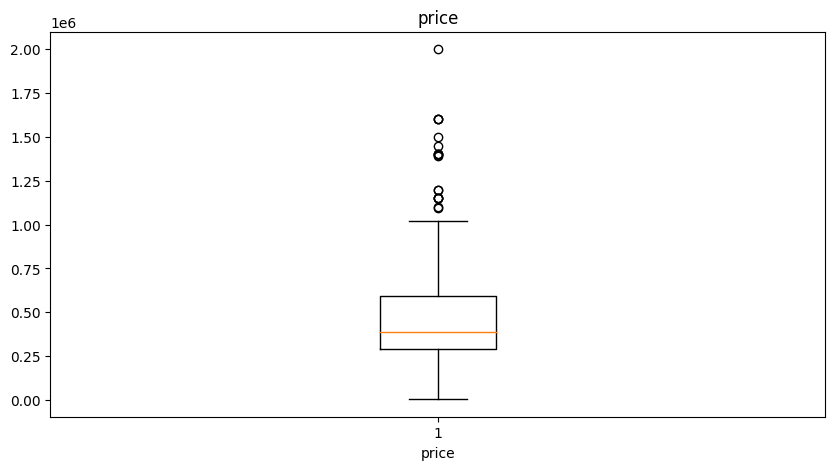

In [ ]:
# outliers price()

plt.figure(figsize=(10, 5))  # Configurar el tamaño de la figura
plt.boxplot(df3['price'])  # Crear el boxplot horizontal
plt.title('price')  # Añadir el título del gráfico
plt.xlabel('price')  # Añadir la etiqueta del eje X


plt.show()  # Mostrar el boxplot

In [ ]:
# Crear una máscara booleana para las filas donde 'price' está entre 30000 y 300000
mask = (df3['price'] >= 50000) & (df3['price'] <= 750000)

df3 = df3[mask]

print(df3['price'].describe())

count       552.000000
mean     400136.753224
std      167331.182311
min       80000.000000
25%      280000.000000
50%      365000.000000
75%      531250.000000
max      750000.000000
Name: price, dtype: float64


In [ ]:
df3.shape

(552, 20)

### Precio m2 x sup total x l3 (mediana)

In [ ]:
# Precio por metro cuadrado por cada barrio por superficie
precio_por_m2_por_barrio = df3.groupby('l3')['price'].sum() / df3.groupby('l3')['surface_total'].sum()

df3['precio_por_m2'] = df3['l3'].map(precio_por_m2_por_barrio)

df3['precio_ajustado'] = df3['precio_por_m2'] * df3['surface_total']

print("Resultados completos:")
print(df3[['l3', 'price', 'surface_total', 'precio_por_m2', 'precio_ajustado']])

Resultados completos:
                   l3     price  surface_total  precio_por_m2  precio_ajustado
id                                                                            
952540  Puerto Madero  595000.0          112.0    5134.848025    575102.978758
849850  Puerto Madero  265000.0           56.0    5134.848025    287551.489379
391593  Puerto Madero  319000.0           81.0    5134.848025    415922.689995
10500   Puerto Madero  485000.0           88.0    5134.848025    451866.626167
64597   Puerto Madero  525000.0           80.0    5134.848025    410787.841970
...               ...       ...            ...            ...              ...
987485  Puerto Madero  277900.0           69.0    5134.848025    354304.513699
987498  Puerto Madero  720000.0          117.0    5134.848025    600777.218882
987510  Puerto Madero  285000.0           76.0    5134.848025    390248.449872
993633  Puerto Madero  360000.0           48.0    5134.848025    246472.705182
994329  Puerto Madero  420000.

In [ ]:
df3.precio_ajustado

id
952540    575102.978758
849850    287551.489379
391593    415922.689995
10500     451866.626167
64597     410787.841970
              ...      
987485    354304.513699
987498    600777.218882
987510    390248.449872
993633    246472.705182
994329    338899.969626
Name: precio_ajustado, Length: 552, dtype: float64

In [ ]:
df3.isna().sum()

ad_type                            0
start_date                         0
end_date                           0
created_on                         0
lon                                0
lat                                0
l2                                 0
l3                                 0
rooms                              0
bedrooms                           0
bathrooms                          0
surface_total                      0
surface_covered                    0
currency                           0
title                              0
description                        0
property_type                      0
operation_type                     0
price                              0
bathrooms_greater_than_bedrooms    0
precio_por_m2                      0
precio_ajustado                    0
dtype: int64

In [ ]:
df3 = df3.drop(columns=['precio_por_m2', 'bathrooms_greater_than_bedrooms'])

In [ ]:
# Se calculan outliers con el nuevo precio
df3['diferencia_precio_real_ajustado'] = df3['price'] - df3['precio_ajustado']

std_dev = df3['diferencia_precio_real_ajustado'].std()
mean_diff = df3['diferencia_precio_real_ajustado'].mean()

outliers = df3[df3['diferencia_precio_real_ajustado'].abs() > 1 * std_dev]


numero_observaciones = outliers.shape[0]

print(f"Número de observaciones que son outliers: {numero_observaciones}")


Número de observaciones que son outliers: 21


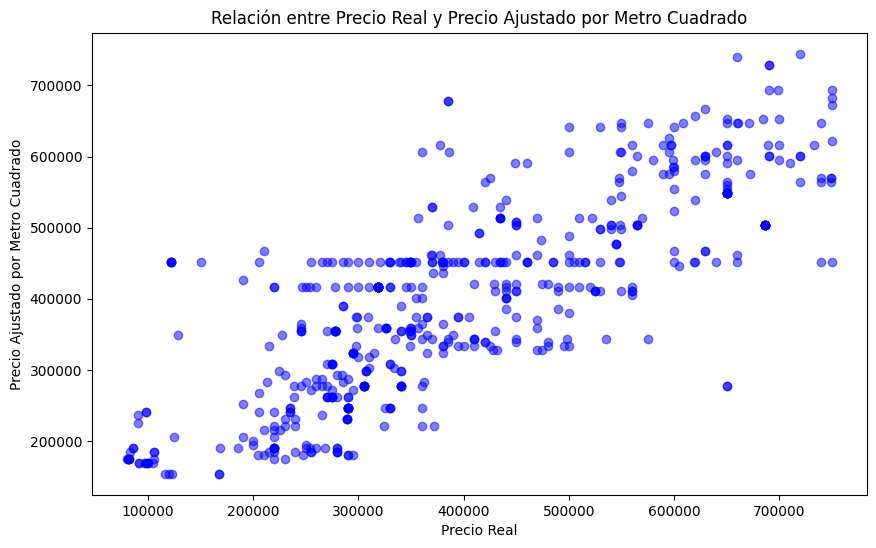

In [ ]:
# Se crean figuras y ejes
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df3['price'], df3['precio_ajustado'], alpha=0.5, color='blue')

ax.set_xlabel('Precio Real')
ax.set_ylabel('Precio Ajustado por Metro Cuadrado')
ax.set_title('Relación entre Precio Real y Precio Ajustado por Metro Cuadrado')

plt.show()

In [ ]:
# Se calculan outliers con el nuevo precio
df3['diferencia_precio_real_ajustado'] = df3['price'] - df3['precio_ajustado']

std_dev = df3['diferencia_precio_real_ajustado'].std()
mean_diff = df3['diferencia_precio_real_ajustado'].mean()

outliers = df3[df3['diferencia_precio_real_ajustado'].abs() > 1.2 * std_dev]


numero_observaciones = outliers.shape[0]

print(f"Número de observaciones que son outliers: {numero_observaciones}")


Número de observaciones que son outliers: 96


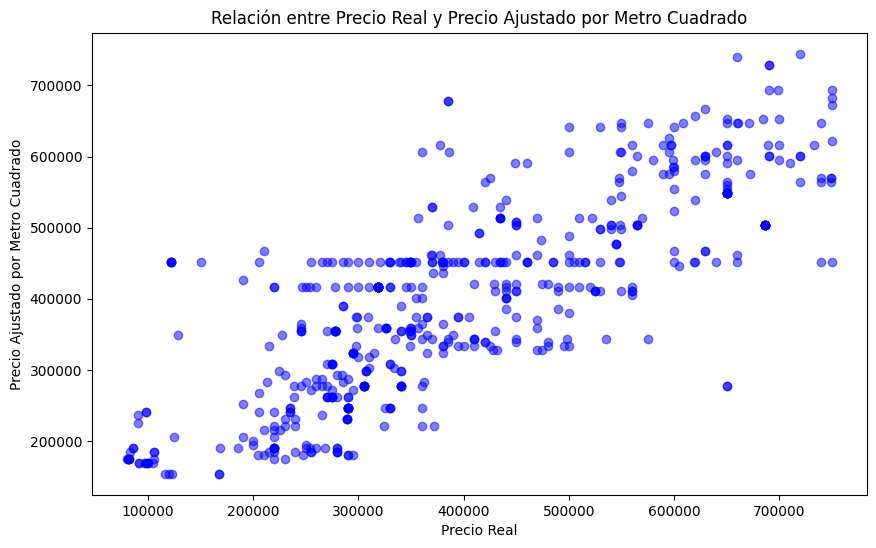

In [ ]:
# Se crean figuras y ejes
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df3['price'], df3['precio_ajustado'], alpha=0.5, color='blue')

ax.set_xlabel('Precio Real')
ax.set_ylabel('Precio Ajustado por Metro Cuadrado')
ax.set_title('Relación entre Precio Real y Precio Ajustado por Metro Cuadrado')

plt.show()

### MODELO 17

In [ ]:
df23 = df3.copy()

In [ ]:
df23.shape

(552, 21)

In [ ]:
df23.isna().sum()

ad_type                            0
start_date                         0
end_date                           0
created_on                         0
lon                                0
lat                                0
l2                                 0
l3                                 0
rooms                              0
bedrooms                           0
bathrooms                          0
surface_total                      0
surface_covered                    0
currency                           0
title                              0
description                        0
property_type                      0
operation_type                     0
price                              0
precio_ajustado                    0
diferencia_precio_real_ajustado    0
dtype: int64

In [ ]:
df23.fillna(0, inplace=True)

In [ ]:
df23.dtypes

ad_type                             object
start_date                          object
end_date                            object
created_on                          object
lon                                float64
lat                                float64
l2                                  object
l3                                  object
rooms                              float64
bedrooms                           float64
bathrooms                          float64
surface_total                      float64
surface_covered                    float64
currency                            object
title                               object
description                         object
property_type                       object
operation_type                      object
price                              float64
precio_ajustado                    float64
diferencia_precio_real_ajustado    float64
dtype: object

In [ ]:
df23 = df23.select_dtypes(exclude=["object"])

In [ ]:
X = df23[df23.columns.drop("price")]
y = df23["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

71969.16629825138

[Text(0.5, 0.875, 'precio_ajustado <= 457001.469\nfriedman_mse = 27601568043.338\nsamples = 441\nvalue = 398094.794'),
 Text(0.25, 0.625, 'surface_covered <= 53.5\nfriedman_mse = 14732037479.846\nsamples = 317\nvalue = 324481.479'),
 Text(0.125, 0.375, 'diferencia_precio_real_ajustado <= -36975.148\nfriedman_mse = 6058347176.276\nsamples = 113\nvalue = 222882.336'),
 Text(0.0625, 0.125, 'friedman_mse = 5027769619.011\nsamples = 31\nvalue = 130884.387'),
 Text(0.1875, 0.125, 'friedman_mse = 2038665140.559\nsamples = 82\nvalue = 257662.049'),
 Text(0.375, 0.375, 'diferencia_precio_real_ajustado <= 28333.835\nfriedman_mse = 10651581008.844\nsamples = 204\nvalue = 380759.436'),
 Text(0.3125, 0.125, 'friedman_mse = 4204194577.009\nsamples = 132\nvalue = 327263.773'),
 Text(0.4375, 0.125, 'friedman_mse = 7606400982.954\nsamples = 72\nvalue = 478834.819'),
 Text(0.75, 0.625, 'diferencia_precio_real_ajustado <= -42670.402\nfriedman_mse = 11233640443.157\nsamples = 124\nvalue = 586283.669'),
 T

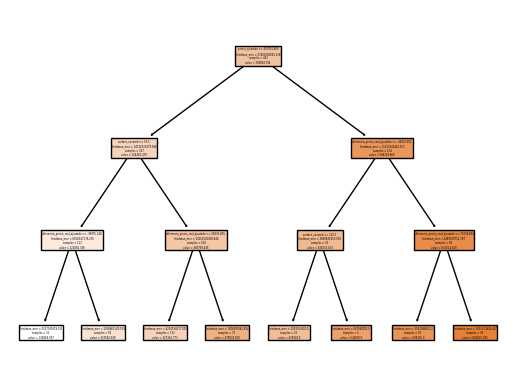

In [ ]:
# Visualización de como el modelo toma las decisiones
sk.tree.plot_tree(reg, feature_names=X_train.columns, filled=True)

***Se observa una mejora notable en el valor del RMSE en Puerto Madero ya que de 228.366 en el modelo 16 se paso a un RMSE de 71.969 en el modelo 17***

## Exportación de las bases limpias

In [ ]:
df3.to_csv(DATA_DIR / "df3_limpio.csv", index=False)

In [ ]:
df4.to_csv(DATA_DIR / "df4_limpio.csv.gz", index=False, compression="gzip")

# MODELO 18 VARIABLES DUMMY

In [ ]:
df20 = df4.copy()

In [ ]:
# Convertir la variable categórica 'l3' en variable numérica

df20 = pd.get_dummies(df4, columns=['l3'], prefix='l3_dummy', drop_first=True)

In [ ]:
df20.shape

(49021, 74)

In [ ]:
df20.isna().sum()

ad_type                      0
start_date                   0
end_date                     0
created_on                   0
lon                          0
                            ..
l3_dummy_Villa Riachuelo     0
l3_dummy_Villa Santa Rita    0
l3_dummy_Villa Soldati       0
l3_dummy_Villa Urquiza       0
l3_dummy_Villa del Parque    0
Length: 74, dtype: int64

In [ ]:
df20.fillna(0, inplace=True)

In [ ]:
df20 = df20.applymap(lambda x: float(x) if isinstance(x, bool) else x)

In [ ]:
df20.dtypes

lon                          float64
lat                          float64
rooms                        float64
bedrooms                     float64
bathrooms                    float64
                              ...   
l3_dummy_Villa Riachuelo     float64
l3_dummy_Villa Santa Rita    float64
l3_dummy_Villa Soldati       float64
l3_dummy_Villa Urquiza       float64
l3_dummy_Villa del Parque    float64
Length: 64, dtype: object

In [ ]:
df20 = df20.select_dtypes(include=['float64', 'int64', 'bool'])

In [ ]:
X = df20[df20.columns.drop("price")]
y = df20["price"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamos el modelo con los datos de entrenamiento
reg = sk.tree.DecisionTreeRegressor(max_depth=3, criterion="friedman_mse", random_state=42)

reg.fit(X_train, y_train)

# y predecimos los valores de prueba
y_pred = reg.predict(X_test)

# evaluamos
sk.metrics.mean_squared_error(y_test, y_pred, squared=False)

17203.58506256972

# 4 - MODELOS PREDICTIVOS

In [ ]:
df21 = df4.copy()

In [ ]:
df21.isna().sum()

ad_type            0
start_date         0
end_date           0
created_on         0
lon                0
lat                0
l2                 0
l3                 0
rooms              0
bedrooms           0
bathrooms          0
surface_total      0
surface_covered    0
currency           0
title              0
description        0
property_type      0
operation_type     0
price              0
precio_ajustado    0
dtype: int64

In [ ]:
df21.dtypes

ad_type             object
start_date          object
end_date            object
created_on          object
lon                float64
lat                float64
l2                  object
l3                  object
rooms              float64
bedrooms           float64
bathrooms          float64
surface_total      float64
surface_covered    float64
currency            object
title               object
description         object
property_type       object
operation_type      object
price              float64
precio_ajustado    float64
dtype: object

In [ ]:
df21.shape


(49021, 20)

In [ ]:
df21 = df21.select_dtypes(exclude=["object"])

In [ ]:
X = df21.drop(columns='price')
y = df21['price']

In [ ]:
X = (X - X.min()) / (X.max() - X.min())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Random Forest

In [ ]:
rf_reg = RandomForestRegressor()
max_depth = [5,10,15]
n_estimators = [100,200,300]
max_features = [1,2,3,4,5,6,7]
grid = dict(max_depth = max_depth, n_estimators = n_estimators, max_features = max_features)
random_search_rf = RandomizedSearchCV(rf_reg, grid, n_iter = 25, scoring = 'neg_root_mean_squared_error',n_jobs=-1,\
                                      cv = 7, verbose = 3)
mejor_modelo_rf = random_search_rf.fit(X_train,y_train)

Fitting 7 folds for each of 25 candidates, totalling 175 fits


In [ ]:
print("Mejores parámetros encontrados:")
print(mejor_modelo_rf.best_params_)

Mejores parámetros encontrados:
{'n_estimators': 300, 'max_features': 5, 'max_depth': 15}


In [ ]:
print("Mejor RMSE promedio en validación cruzada:")
print(mejor_modelo_rf.best_score_)

Mejor RMSE promedio en validación cruzada:
-12183.501879796215


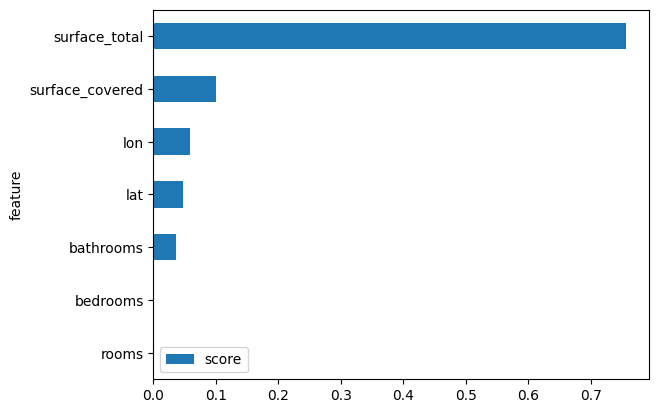

In [ ]:
df21_scores = pd.DataFrame({"feature": X.columns, "score": reg.feature_importances_}).sort_values(by="score")
df21_scores.plot.barh("feature", "score");

In [ ]:
pd.DataFrame(random_search_rf.cv_results_)[['params', 'mean_test_score']].sort_values('mean_test_score', ascending = False)

,params,mean_test_score
3,"{'n_estimators': 300, 'max_features': 5, 'max_...",-12183.501880
14,"{'n_estimators': 200, 'max_features': 6, 'max_...",-12232.257139
17,"{'n_estimators': 100, 'max_features': 6, 'max_...",-12251.408315
19,"{'n_estimators': 300, 'max_features': 2, 'max_...",-12281.439123
1,"{'n_estimators': 200, 'max_features': 2, 'max_...",-12295.052284
4,"{'n_estimators': 100, 'max_features': 7, 'max_...",-12300.638899
0,"{'n_estimators': 100, 'max_features': 2, 'max_...",-12301.527404
5,"{'n_estimators': 200, 'max_features': 5, 'max_...",-13680.985948
16,"{'n_estimators': 200, 'max_features': 6, 'max_...",-13693.306561
18,"{'n_estimators': 100, 'max_features': 6, 'max_...",-13694.943276


*MODELO PREDICTIVO RANDOM FOREST*

La optimización de los parámetros se realizó mediante RandomizedSearchCV
- La validación cruzada de 7.
- max_depth de 10, 15 y 20.
- n_estimators de 100, 300 y 500.
- max_features entre 2 y 7




## KNeighbors

In [ ]:
# intancia del modelo de ML seleccionado
knn_reg = KNeighborsRegressor()

# valores de los hiperparámetros a modelar
n_neighbors = [10,30,60,90,120,150]
weights = ['distance', 'uniform']
metric = ['euclidean', "cityblock"]

grid = dict(n_neighbors = n_neighbors, weights = weights, metric=metric)



random_search_knn = RandomizedSearchCV(knn_reg, grid, n_iter = 25, scoring = 'neg_root_mean_squared_error',\
                                       n_jobs=-1, cv = 10, verbose = 3)
modelo_knn = random_search_knn.fit(X_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 24 is smaller than n_iter=25. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 10 folds for each of 24 candidates, totalling 240 fits


In [ ]:
print("Mejores hiperparámetros encontrados:")
print(modelo_knn.best_params_)

Mejores hiperparámetros encontrados:
{'weights': 'distance', 'n_neighbors': 30, 'metric': 'cityblock'}


In [ ]:
print("RMSE promedio en la validación cruzada:")
print(-modelo_knn.best_score_)

RMSE promedio en la validación cruzada:
12236.902378222654


In [ ]:
pd.DataFrame(random_search_knn.cv_results_)[['params', 'mean_test_score']].sort_values('mean_test_score', ascending = False)

,params,mean_test_score
14,"{'weights': 'distance', 'n_neighbors': 30, 'me...",-12236.902378
16,"{'weights': 'distance', 'n_neighbors': 60, 'me...",-12331.005328
12,"{'weights': 'distance', 'n_neighbors': 10, 'me...",-12354.611888
2,"{'weights': 'distance', 'n_neighbors': 30, 'me...",-12368.990713
18,"{'weights': 'distance', 'n_neighbors': 90, 'me...",-12442.568255
0,"{'weights': 'distance', 'n_neighbors': 10, 'me...",-12464.795273
4,"{'weights': 'distance', 'n_neighbors': 60, 'me...",-12517.508836
20,"{'weights': 'distance', 'n_neighbors': 120, 'm...",-12551.044199
22,"{'weights': 'distance', 'n_neighbors': 150, 'm...",-12661.197256
6,"{'weights': 'distance', 'n_neighbors': 90, 'me...",-12680.453974


KNeighbors

El resultado óptimo se da con la combinación de hiperparámetros {'weights': 'distance', 'n_neighbors': 30, 'metric': 'cityblock'} y con el menor error cuadrático medio promedio de la validación cruzada de -12236.90

## HISTGRADIENT BOOSTING

In [ ]:
hgb_rg = HistGradientBoostingRegressor()
learning_rate = [0.1, 0.2, 0.3, 0.4, 0.5]
max_iter = [100,500,1000]
max_depth = [3,6,9,12,18]
l2_regularization = [0.1,0.2,0.3,0.4]

grid = dict(learning_rate= learning_rate,max_iter=max_iter,max_depth = max_depth,l2_regularization=l2_regularization)

from sklearn.model_selection import RandomizedSearchCV

random_search_hgb = RandomizedSearchCV(hgb_rg, grid, n_iter = 25, scoring = 'neg_root_mean_squared_error',\
                                       n_jobs=-1, cv = 10, verbose = 3)

mejor_modelo_hgb = random_search_hgb.fit(X_train,y_train)

Fitting 10 folds for each of 25 candidates, totalling 250 fits


In [ ]:
random_search_hgb.best_params_

{'max_iter': 1000,
 'max_depth': 18,
 'learning_rate': 0.4,
 'l2_regularization': 0.1}

In [ ]:
random_search_hgb.best_score_

-12727.119992599999

In [ ]:
pd.DataFrame(random_search_hgb.cv_results_)[['params', 'mean_test_score']].sort_values('mean_test_score', ascending = False)


,params,mean_test_score
3,"{'max_iter': 1000, 'max_depth': 18, 'learning_...",-12727.119993
1,"{'max_iter': 1000, 'max_depth': 12, 'learning_...",-12783.346300
20,"{'max_iter': 1000, 'max_depth': 9, 'learning_r...",-12834.368628
16,"{'max_iter': 500, 'max_depth': 18, 'learning_r...",-12847.540477
0,"{'max_iter': 500, 'max_depth': 12, 'learning_r...",-12907.035121
17,"{'max_iter': 1000, 'max_depth': 9, 'learning_r...",-13005.115728
24,"{'max_iter': 100, 'max_depth': 12, 'learning_r...",-13104.884361
9,"{'max_iter': 100, 'max_depth': 9, 'learning_ra...",-13106.570477
22,"{'max_iter': 100, 'max_depth': 9, 'learning_ra...",-13196.122551
8,"{'max_iter': 100, 'max_depth': 6, 'learning_ra...",-13200.683735


## Random Forest - Puerto Madero

In [ ]:
df23 = df3.copy()

In [ ]:
df23.isna().sum()

ad_type                            0
start_date                         0
end_date                           0
created_on                         0
lon                                0
lat                                0
l2                                 0
l3                                 0
rooms                              0
bedrooms                           0
bathrooms                          0
surface_total                      0
surface_covered                    0
currency                           0
title                              0
description                        0
property_type                      0
operation_type                     0
price                              0
precio_ajustado                    0
diferencia_precio_real_ajustado    0
dtype: int64

In [ ]:
df23.dtypes

ad_type                             object
start_date                          object
end_date                            object
created_on                          object
lon                                float64
lat                                float64
l2                                  object
l3                                  object
rooms                              float64
bedrooms                           float64
bathrooms                          float64
surface_total                      float64
surface_covered                    float64
currency                            object
title                               object
description                         object
property_type                       object
operation_type                      object
price                              float64
precio_ajustado                    float64
diferencia_precio_real_ajustado    float64
dtype: object

In [ ]:
df23.shape


(552, 21)

In [ ]:
df23 = df23.select_dtypes(exclude=["object"])

In [ ]:
X = df23.drop(columns='price')
y = df23['price']

In [ ]:
X = (X - X.min()) / (X.max() - X.min())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rf_reg = RandomForestRegressor()
max_depth = [5,10,15]
n_estimators = [100,200,300]
max_features = [1,2,3,4,5,6,7]
grid = dict(max_depth = max_depth, n_estimators = n_estimators, max_features = max_features)
random_search_rf = RandomizedSearchCV(rf_reg, grid, n_iter = 25, scoring = 'neg_root_mean_squared_error',n_jobs=-1,\
                                      cv = 7, verbose = 3)
mejor_modelo_rf = random_search_rf.fit(X_train,y_train)

Fitting 7 folds for each of 25 candidates, totalling 175 fits


In [ ]:
print("Mejores parámetros encontrados:")
print(mejor_modelo_rf.best_params_)

Mejores parámetros encontrados:
{'n_estimators': 300, 'max_features': 7, 'max_depth': 15}


In [ ]:
print("Mejor RMSE promedio en validación cruzada:")
print(mejor_modelo_rf.best_score_)

Mejor RMSE promedio en validación cruzada:
-23228.183735848088


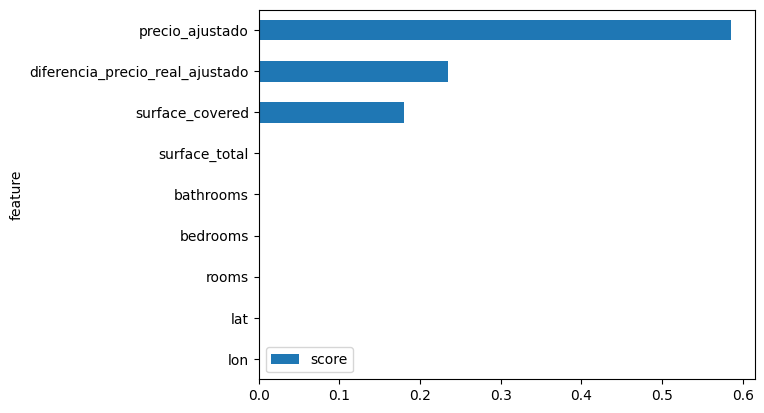

In [ ]:
df23_scores = pd.DataFrame({"feature": X.columns, "score": reg.feature_importances_}).sort_values(by="score")
df23_scores.plot.barh("feature", "score");

In [ ]:
pd.DataFrame(random_search_rf.cv_results_)[['params', 'mean_test_score']].sort_values('mean_test_score', ascending = False)

,params,mean_test_score
15,"{'n_estimators': 300, 'max_features': 7, 'max_...",-23228.183736
1,"{'n_estimators': 100, 'max_features': 7, 'max_...",-23326.651261
13,"{'n_estimators': 200, 'max_features': 7, 'max_...",-23450.414702
12,"{'n_estimators': 200, 'max_features': 7, 'max_...",-23803.102044
9,"{'n_estimators': 300, 'max_features': 6, 'max_...",-23900.864062
4,"{'n_estimators': 200, 'max_features': 5, 'max_...",-24815.893904
18,"{'n_estimators': 100, 'max_features': 5, 'max_...",-25214.373175
7,"{'n_estimators': 100, 'max_features': 4, 'max_...",-25871.998596
8,"{'n_estimators': 300, 'max_features': 4, 'max_...",-26755.391293
16,"{'n_estimators': 300, 'max_features': 4, 'max_...",-26910.614692


In [ ]:
importances = mejor_modelo_rf.best_estimator_.feature_importances_
df_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)
print("Importancia de las características:")
print(df_importances.head(10))  # Mostrar las 10 características más importantes

Importancia de las características:
                           Feature  Importance
6                  surface_covered    0.313285
8  diferencia_precio_real_ajustado    0.240957
7                  precio_ajustado    0.209055
5                    surface_total    0.192934
0                              lon    0.029926
1                              lat    0.008439
2                            rooms    0.003841
3                         bedrooms    0.000817
4                        bathrooms    0.000745


- El RMSE promedio registrado para Puerto Madero fue de 23.228.
- La superficie cubierta presentó la mayor importancia en el Random Forest de este segmento.
- `precio_ajustado` y `diferencia_precio_real_ajustado` también tuvieron una participación elevada; como se construyen a partir del precio publicado, deben interpretarse como variables de análisis exploratorio y no como atributos disponibles para una tasación nueva.